In [5]:
import sys, os
if "venv" not in sys.executable:
    venv_python = os.path.join(
        os.path.dirname(__file__), "venv",
        "Scripts" if os.name == "nt" else "bin",
        "python.exe" if os.name == "nt" else "python",
    )
    os.execv(venv_python, [sys.executable, __file__])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import GRU, Dense


def load_yf_data(symbol):
    ticker = yf.Ticker(symbol)
    data = ticker.history(period="2y")
    print(f"\n{data}")
    return data


def create_dataset(features, target, look_back=1):
    """features: 2D array (n, num_features). target: 2D array (n, 1)."""
    dataX, dataY = [], []
    for i in range(len(features) - look_back - 1):
        dataX.append(features[i:(i + look_back), :])
        dataY.append(target[i + look_back, 0])
    return np.array(dataX), np.array(dataY)


yf_data = load_yf_data("CEG")
yf_data.info()

yf_data.hist(bins=40, figsize=(12, 8))
plt.show()

# --- Separate scalers for inputs (multi-feature) and target (Close only).
# One scaler for both breaks inverse_transform once the model only predicts
# a single value (Dense(1)) but the scaler was fit on many columns.
feature_cols = ['Close', 'Volume', 'High', 'Low']
raw_features = yf_data[feature_cols].values
raw_target = yf_data[['Close']].values

feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = feature_scaler.fit_transform(raw_features)

target_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_target = target_scaler.fit_transform(raw_target)

train_ratio = 0.67
train_size = int(len(scaled_features) * train_ratio)

train_features, test_features = scaled_features[:train_size, :], scaled_features[train_size:, :]
train_target, test_target = scaled_target[:train_size, :], scaled_target[train_size:, :]
print(train_size, len(scaled_features) - train_size)

look_back = 10
trainX, trainY = create_dataset(train_features, train_target, look_back)
testX, testY = create_dataset(test_features, test_target, look_back)

# trainX is already (samples, look_back, num_features) - no reshape needed
num_features = len(feature_cols)

epochNo = 100
batchSize = 10

model = tf.keras.Sequential()
model.add(GRU(32, input_shape=(look_back, num_features)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=200, batch_size=32, verbose=2)

trainPredict = model.predict(trainX)
trainPredict = target_scaler.inverse_transform(trainPredict)
trainY = target_scaler.inverse_transform(trainY.reshape(-1, 1))

testPredict = model.predict(testX)
testPredict = target_scaler.inverse_transform(testPredict)
testY = target_scaler.inverse_transform(testY.reshape(-1, 1))

actual_prices = target_scaler.inverse_transform(scaled_target)

trainPredictPlot = np.empty_like(actual_prices)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict) + look_back, :] = trainPredict

testPredictPlot = np.empty_like(actual_prices)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict) + (look_back * 2) + 1:len(actual_prices) - 1, :] = testPredict

plt.plot(actual_prices, label="Actual")
plt.plot(trainPredictPlot, label="Train predict")
plt.plot(testPredictPlot, label="Test predict")
plt.legend()
plt.show()

KeyboardInterrupt: 

Naive Baseline RMSE: 8.18
Train Score: 10.56 RMSE
Test Score: 8.57 RMSE


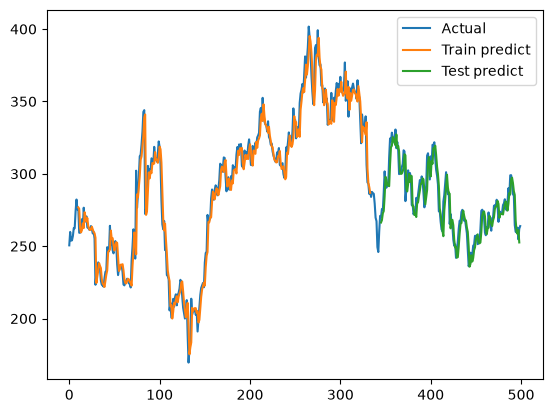

In [ ]:
naive_pred = testY[:-1, 0]
naive_actual = testY[1:, 0]
naive_score = np.sqrt(mean_squared_error(naive_actual, naive_pred))
print('Naive Baseline RMSE: %.2f' % (naive_score))

trainScore = np.sqrt(mean_squared_error(trainY[:, 0], trainPredict[:, 0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[:, 0], testPredict[:, 0]))
print('Test Score: %.2f RMSE' % (testScore))

plt.plot(actual_prices, label="Actual")
plt.plot(trainPredictPlot, label="Train predict")
plt.plot(testPredictPlot, label="Test predict")
plt.legend()
plt.show()

In [ ]:
import sys, os
if "venv" not in sys.executable:
    venv_python = os.path.join(
        os.path.dirname(__file__), "venv",
        "Scripts" if os.name == "nt" else "bin",
        "python.exe" if os.name == "nt" else "python",
    )
    os.execv(venv_python, [sys.executable, __file__])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


def load_yf_data(symbol, period="12month"):
    ticker = yf.Ticker(symbol)
    data = ticker.history(period=period)
    print(f"\n{data}")
    return data


def create_dataset(features, target, look_back=1):
    """features: 2D array (n, num_features). target: 2D array (n, 1)."""
    dataX, dataY = [], []
    for i in range(len(features) - look_back - 1):
        dataX.append(features[i:(i + look_back), :])
        dataY.append(target[i + look_back, 0])
    return np.array(dataX), np.array(dataY)


yf_data = load_yf_data("CEG", period="12mo")
yf_data.info()

# --- FRAME AS RETURNS instead of raw price ---
# Predicting price directly is close to predicting a random walk. The
# next-day % change is a more stationary, more learnable target, and its
# sign is directly the thing that matters for "would this make money."
df = yf_data.copy()
df['Return'] = df['Close'].pct_change()
df = df.dropna()

feature_cols = ['Close', 'Volume', 'High', 'Low']
raw_features = df[feature_cols].values
raw_target = df[['Return']].values
train_ratio = 0.80
train_size = int(len(scaled_features) * train_ratio)
feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = feature_scaler.fit_transform(raw_features)
target_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_target = target_scaler.fit_transform(raw_target)

train_features, test_features = scaled_features[:train_size, :], scaled_features[train_size:, :]
train_target, test_target = scaled_target[:train_size, :], scaled_target[train_size:, :]
print(f"train samples: {train_size}, test samples: {len(scaled_features) - train_size}")

look_back = 5
trainX, trainY = create_dataset(train_features, train_target, look_back)
testX, testY = create_dataset(test_features, test_target, look_back)

num_features = len(feature_cols)

epochNo = 150
batchSize = 10

from tensorflow.keras.optimizers import Adam

model = tf.keras.Sequential()
model.add(GRU(4, input_shape=(look_back, num_features)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.005))

model.fit(
    trainX, trainY,
    epochs=epochNo, batch_size=batchSize, verbose=2,
    validation_split=0.2,
)

trainPredict = model.predict(trainX)
trainPredict = target_scaler.inverse_transform(trainPredict)
trainY_actual = target_scaler.inverse_transform(trainY.reshape(-1, 1))

testPredict = model.predict(testX)
testPredict = target_scaler.inverse_transform(testPredict)
testY_actual = target_scaler.inverse_transform(testY.reshape(-1, 1))

# --- Naive baseline for returns: "tomorrow's return = 0% (no change)" ---



                                 Open        High         Low       Close  \
Date                                                                        
2025-09-23 00:00:00-04:00  344.822393  346.503001  334.271390  334.778534   
2025-09-24 00:00:00-04:00  337.800634  342.485444  333.634926  337.244751   
2025-09-25 00:00:00-04:00  333.137716  334.689041  323.252971  324.515900   
2025-09-26 00:00:00-04:00  326.892630  330.989721  324.625305  329.418518   
2025-09-29 00:00:00-04:00  333.038279  338.651918  320.766881  332.406830   
...                               ...         ...         ...         ...   
2026-09-16 00:00:00-04:00  262.600006  263.260010  254.710007  259.529999   
2026-09-17 00:00:00-04:00  264.869995  269.399994  259.320007  262.799988   
2026-09-18 00:00:00-04:00  260.250000  262.420013  254.559998  254.710007   
2026-09-21 00:00:00-04:00  256.380005  265.850006  250.550003  262.109985   
2026-09-22 00:00:00-04:00         NaN         NaN         NaN         NaN  

c:\Users\Conner\Desktop\github_repository\StockAnalysisBot\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 - 1s - 54ms/step - loss: 0.1858 - val_loss: 0.0534
Epoch 2/150
16/16 - 0s - 4ms/step - loss: 0.0478 - val_loss: 0.0330
Epoch 3/150
16/16 - 0s - 4ms/step - loss: 0.0326 - val_loss: 0.0269
Epoch 4/150
16/16 - 0s - 4ms/step - loss: 0.0335 - val_loss: 0.0314
Epoch 5/150
16/16 - 0s - 4ms/step - loss: 0.0316 - val_loss: 0.0298
Epoch 6/150
16/16 - 0s - 4ms/step - loss: 0.0306 - val_loss: 0.0308
Epoch 7/150
16/16 - 0s - 4ms/step - loss: 0.0307 - val_loss: 0.0311
Epoch 8/150
16/16 - 0s - 4ms/step - loss: 0.0304 - val_loss: 0.0304
Epoch 9/150
16/16 - 0s - 4ms/step - loss: 0.0310 - val_loss: 0.0327
Epoch 10/150
16/16 - 0s - 4ms/step - loss: 0.0306 - val_loss: 0.0307
Epoch 11/150
16/16 - 0s - 4ms/step - loss: 0.0315 - val_loss: 0.0260
Epoch 12/150
16/16 - 0s - 4ms/step - loss: 0.0302 - val_loss: 0.0348
Epoch 13/150
16/16 - 0s - 4ms/step - loss: 0.0307 - val_loss: 0.0278
Epoch 14/150
16/16 - 0s - 4ms/step - loss: 0.0302 - val_loss: 0.0298
Epoch 15/150
16/16 - 0s - 4ms/step - loss: 0.0299 - va

train samples: 193, test samples: 44
Naive Baseline RMSE (predict 0% return): 0.0242
Train Score: 0.0318 RMSE
Test Score: 0.0248 RMSE
Directional Accuracy: 47.73%  (50% = random guessing)


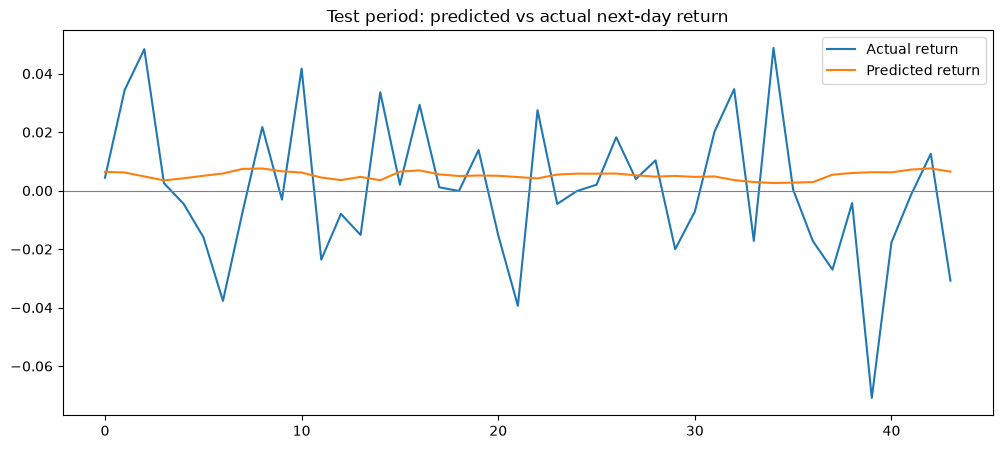

In [ ]:
print(f"train samples: {len(trainY)}, test samples: {len(testY)}")
naive_score = np.sqrt(mean_squared_error(testY_actual[:, 0], np.zeros_like(testY_actual[:, 0])))
print('Naive Baseline RMSE (predict 0%% return): %.4f' % (naive_score))

trainScore = np.sqrt(mean_squared_error(trainY_actual[:, 0], trainPredict[:, 0]))
print('Train Score: %.4f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY_actual[:, 0], testPredict[:, 0]))
print('Test Score: %.4f RMSE' % (testScore))

# --- Directional accuracy: the metric that actually matters for trading ---
pred_direction = np.sign(testPredict[:, 0])
actual_direction = np.sign(testY_actual[:, 0])
directional_accuracy = np.mean(pred_direction == actual_direction)
print('Directional Accuracy: %.2f%%  (50%% = random guessing)' % (directional_accuracy * 100))

# --- Plot predicted vs actual returns for the test period ---
plt.figure(figsize=(12, 5))
plt.plot(testY_actual[:, 0], label="Actual return")
plt.plot(testPredict[:, 0], label="Predicted return")
plt.axhline(0, color='gray', linewidth=0.8)
plt.legend()
plt.title("Test period: predicted vs actual next-day return")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

def one_period_returns(P: np.ndarray) -> np.ndarray:

    return P[:-1] / P[1:] - 1


def momentum_stats(P: np.ndarray, S: int, T: int) -> dict:

    if len(P) < S + T + 1:
        return {"R_cum": np.nan, "R_mean": np.nan, "sigma": np.nan, "R_riskadj": np.nan}

    r = one_period_returns(P)              # r[t] = R(t)
    window = r[S:S + T]                    # R(S) ... R(S+T-1)

    R_cum = P[S] / P[S + T] - 1
    R_mean = window.mean()
    sigma2 = ((window - R_mean) ** 2).sum() / (T - 1)
    sigma = np.sqrt(sigma2)
    R_riskadj = R_mean / sigma if sigma > 0 else np.nan

    return {"R_cum": R_cum, "R_mean": R_mean, "sigma": sigma, "R_riskadj": R_riskadj}


def download_prices(tickers: list[str], period: str = "3y") -> pd.DataFrame:

    data = yf.download(
        tickers,
        period=period,
        auto_adjust=True,   # adjusts OHLC for splits AND dividends
        progress=False,
    )["Close"]

    # yf.download returns a Series instead of a DataFrame for a single ticker
    if isinstance(data, pd.Series):
        data = data.to_frame(tickers[0])

    return data.dropna(how="all")


def rank_universe(
    prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
    min_history: int | None = None,
) -> pd.DataFrame:

    if min_history is None:
        min_history = S + T + 1

    rows = []
    for ticker in prices.columns:
        series = prices[ticker].dropna()
        if len(series) < min_history:
            continue

        P = series.to_numpy()[::-1]  # reverse -> P[0] = most recent
        stats = momentum_stats(P, S, T)
        stats["ticker"] = ticker
        rows.append(stats)

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("R_riskadj", ascending=False)
    result["rank"] = range(1, len(result) + 1)

    return result[["rank", "R_cum", "R_mean", "sigma", "R_riskadj"]]


if __name__ == "__main__":
    universe = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
"JPM", "XOM", "PG", "KO",
"GOOG", "AVGO", "TSLA", "MU", "LLY", "AMD", "WMT",
"V", "INTC", "JNJ", "MA", "ABBV", "ORCL", "PLTR", "CSCO",
"COST", "CVX", "BAC", "LRCX", "AMAT", "MRK", "CAT", "DELL",
"UNH", "GE", "MS", "PANW", "HD", "NFLX", "PM", "GS", "SNDK",
"ANET", "RTX", "CRWD", "GEV", "WFC", "TXN", "KLAC", "TMO",
"MRVL", "C", "AMGN", "IBM", "LIN", "QCOM", "STX", "AXP",
"APH", "VZ", "CRM", "DE", "GILD", "ADI", "ABT", "DIS", "PEP",
"MCD", "TMUS", "SCHW", "BLK", "T", "ETN", "WDC", "WELL", "NEE",
"UNP", "PFE", "BA", "DHR", "BX", "COP", "TJX", "UBER", "ISRG",
"NOW", "GLW", "NEM", "PLD", "VRTX", "CB", "FTNT", "BMY", "BKNG",
"COF", "PH", "LMT", "PGR", "SPGI", "MDT", "MO", "ACN", "HOOD",
"CVS", "LOW", "APP", "MPC", "VLO", "SBUX", "ADP", "FCX", "SYK",
"EQIX", "MCK", "PSX", "BNY", "SO", "VRT", "PWR", "TT", "CME",
"ABNB", "HCA", "ADBE", "CEG", "GD", "USB", "PNC", "MAR", "DUK",
"HWM", "DDOG", "JCI", "KKR", "MMM", "ELV", "WMB", "MNST", "CSX",
"EMR", "ICE", "LITE", "CDNS", "DASH", "WM", "AMT", "UPS", "BE",
"MCO", "MRSH", "HPE", "REGN", "CTAS", "CMCSA", "SHW", "SNPS",
"SPG", "INTU", "MDLZ", "ECL", "WBD", "SLB", "ITW", "MSI", "TRV",
"ROST", "APO", "GM", "EOG", "MRNA", "CVNA", "NOC", "CMI", "CI",
"TGT", "NSC", "DLR", "FDX", "KMI", "ORLY", "HLT", "CL", "MPWR",
"HON", "RSG", "AEP", "BSX", "URI", "APD", "RCL", "TER", "TEL",
"TDG", "MET", "COHR", "AON", "TRGP", "COR", "PCAR", "NXPI", "GWW",
"KEYS", "AJG", "TFC", "CRH", "ALL", "FAST", "AFL", "FIX", "BKR",
"OKE", "OXY", "AME", "PSA", "NUE", "D", "GRMN", "DAL", "DVN",
"CTVA", "NKE", "O", "COIN", "HONA", "SRE", "NDAQ", "CIEN", "F",
"FANG", "CAH", "EW", "BDX", "STT", "WAB", "EBAY", "ETR", "VMRK",
"FITB", "ROK", "A", "VST", "XYZ", "AZO", "ADSK", "CARR", "WDAY",
"AMP", "PYPL", "XEL", "VTR", "LHX", "HUM", "IQV", "EXC", "KDP",
"FERG", "FLEX", "VEEV", "WAT", "IBKR", "CMG", "ARES", "MCHP",
"IDXX", "CBRE", "PAYX", "PRU", "DHI", "MSCI", "ADM", "LYV", "AIG",
"SYY", "TTWO", "ED", "YUM", "NTAP", "UAL", "ILMN", "AXON", "P",
"ODFL", "EL", "ROP", "TKO", "MLM", "IRM", "HIG", "KR", "PEG",
"KVUE", "HSY", "DXCM", "EXPE", "STLD", "WEC", "EME", "BIIB", "KMB",
"JBL", "ACGL", "MTB", "VMC", "EQT", "RMD", "NTRS", "HBAN", "CNC",
"CCI", "RJF", "CCL", "ZTS", "RDDT", "GEHC", "MTD", "EXR", "HPQ",
"IR", "ON", "KHC", "TDY", "PCG", "AEE", "WTW", "CBOE", "ECHO",
"CFG", "WSM", "HAL", "SMCI", "FOXA", "DG", "VRSN", "CPRT", "AWK",
"ATO", "WRB", "CTSH", "VICI", "Q", "WST", "DTE", "OTIS", "DGX",
"FE", "CPAY", "INCY", "LVS", "FFIV", "FOX", "CINF", "LH", "XYL",
"DOV", "ES", "CNP", "PPL", "FISV", "TPL", "EXPD", "SW", "PFG",
"DRI", "HUBB", "PPG", "RF", "ULTA", "SYF", "VLTO", "PHM", "CHD",
"TPR", "GPN", "VRSK", "JBHT", "TROW", "IFF", "KEY", "L", "CASY",
"NRG", "DLTR", "FSLR", "EIX", "BG", "PKG", "BRO", "OMC", "RL",
"LUV", "DOW", "STE", "CMS", "EXE", "STZ", "LEN", "AMCR", "BBY",
"FICO", "VTRS", "SNA", "CHTR", "LYB", "NI", "GIS", "IP", "EFX",
"SBAC", "BR", "CDW", "EVRG", "ESS", "CF", "TSN", "FIS", "ZBH",
"GPC", "NDSN", "DD", "FDXF", "CHRW", "TSCO", "ZBRA", "AKAM", "FTV",
"NVR", "BEN", "LNT", "J", "IEX", "NWS", "GEN", "INVH", "RVTY",
"BALL", "ROL", "NWSA", "WY", "HST", "LDOS", "PTC", "KIM", "SOLV",
"APA", "DOC", "EG", "MAA", "SWK", "TRMB", "ALB", "MAS", "REG",
"IVZ", "CRL", "TYL", "SWKS", "TXT", "AIZ", "MKC", "ALLE", "AVY",
"GL", "SJM", "LII", "GDDY", "HAS", "ERIE", "BAX", "GNRC",
"DVA", "UDR", "CSGP", "LULU", "BXP", "TECH", "PSKY", "PNW", "IT",
"HRL", "ALGN", "DECK", "HII", "AES", "UHS", "CLX", "COO", "JKHY",
"CPT", "FDS", "DPZ", "MGM", "HSIC", "PODD", "FRT", "ARE", "APTV",
"PNR", "WYNN", "AOS", "MOS", "NCLH"]

    prices = download_prices(universe, period="8d")

    ranking = rank_universe(prices, S=1, T=6)

    print(ranking.to_string(float_format=lambda x: f"{x:.4f}"))

        rank   R_cum  R_mean  sigma  R_riskadj
ticker                                        
HUBB       1 -0.0063 -0.0009 0.0216    -0.0399


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

def one_period_returns(P: np.ndarray) -> np.ndarray:
    """R(t) for all t = 0 .. len(P)-2, in the t=0-is-most-recent convention."""
    return P[:-1] / P[1:] - 1


def momentum_stats(P: np.ndarray, S: int, T: int) -> dict:
    """
    Compute R_cum, R_mean, sigma^2, R_riskadj over window [S, S+T-1]
    for one stock's reversed price array P (P[0] = most recent).
    """
    if len(P) < S + T + 1:
        return {"R_cum": np.nan, "R_mean": np.nan, "sigma": np.nan, "R_riskadj": np.nan}

    r = one_period_returns(P)              # r[t] = R(t)
    window = r[S:S + T]                    # R(S) ... R(S+T-1)

    R_cum = P[S] / P[S + T] - 1
    R_mean = window.mean()
    sigma2 = ((window - R_mean) ** 2).sum() / (T - 1)
    sigma = np.sqrt(sigma2)
    R_riskadj = R_mean / sigma if sigma > 0 else np.nan

    return {"R_cum": R_cum, "R_mean": R_mean, "sigma": sigma, "R_riskadj": R_riskadj}

def download_prices(tickers: list[str], period: str = "3y") -> pd.DataFrame:
    """
    Download total-return-adjusted (split + dividend adjusted) DAILY close
    prices for a list of tickers. Columns = tickers, index = dates,
    oldest -> newest.
    """
    data = yf.download(
        tickers,
        period=period,
        auto_adjust=True,   # adjusts OHLC for splits AND dividends
        progress=False,
    )["Close"]

    # yf.download returns a Series instead of a DataFrame for a single ticker
    if isinstance(data, pd.Series):
        data = data.to_frame(tickers[0])

    return data.dropna(how="all")


def resample_monthly(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse daily prices to month-end closes (last trading day of each
    calendar month). Index becomes one row per month, oldest -> newest.
    """
    monthly = prices.resample("ME").last()
    return monthly.dropna(how="all")


def rank_universe(
    prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
    min_history: int | None = None,
) -> pd.DataFrame:
    """
    Rank every ticker in `prices` by risk-adjusted momentum.

    prices : DataFrame, columns = tickers, index = dates (oldest -> newest),
             already at whatever frequency you want S/T measured in
             (this script uses month-end frequency).
    S, T   : formation window params, in the same units as `prices`'
             frequency (months, if `prices` is monthly) -
             skip S periods, then use T periods of returns.
    """
    if min_history is None:
        min_history = S + T + 1

    rows = []
    for ticker in prices.columns:
        series = prices[ticker].dropna()
        if len(series) < min_history:
            continue

        P = series.to_numpy()[::-1]  # reverse -> P[0] = most recent
        stats = momentum_stats(P, S, T)
        stats["ticker"] = ticker
        rows.append(stats)

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("R_riskadj", ascending=False)
    result["rank"] = range(1, len(result) + 1)

    return result[["rank", "R_cum", "R_mean", "sigma", "R_riskadj"]]

def rank_movement(
    monthly_prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
) -> pd.DataFrame:
    """
    Compute the risk-adjusted momentum ranking as of the LATEST month-end
    and as of the PREVIOUS month-end (each using only data available up
    to that point), then merge into one table with a rank_change column.

    rank_change > 0 means the stock's rank IMPROVED (moved toward #1)
    over the past month; rank_change < 0 means it fell.
    """
    if len(monthly_prices) < S + T + 2:
        raise ValueError("Not enough monthly history for this S/T window "
                          "plus one prior month.")

    ranking_now = rank_universe(monthly_prices, S=S, T=T)
    ranking_prev = rank_universe(monthly_prices.iloc[:-1], S=S, T=T)

    merged = ranking_now[["rank", "R_riskadj"]].join(
        ranking_prev[["rank"]], how="inner", lsuffix="_now", rsuffix="_prev"
    )
    merged["rank_change"] = merged["rank_prev"] - merged["rank_now"]
    merged = merged.sort_values("rank_now")
    return merged[["rank_now", "rank_prev", "rank_change", "R_riskadj"]]


def plot_rank_movement(
    movement: pd.DataFrame,
    n_movers: int = 15,
    top_n_current: int = 10,
    out_path: str = "rank_movement.png",
):
    """
    Slope chart: for a readable subset of tickers, draw a line from their
    rank LAST month to their rank THIS month.

    Subset shown = current top `top_n_current` leaders, plus the biggest
    `n_movers` gainers and biggest `n_movers` losers by rank_change, so
    the chart stays legible even with a large universe.
    """
    current_top = movement.nsmallest(top_n_current, "rank_now")
    gainers = movement.nlargest(n_movers, "rank_change")
    losers = movement.nsmallest(n_movers, "rank_change")

    subset = pd.concat([current_top, gainers, losers])
    subset = subset[~subset.index.duplicated()]

    fig, ax = plt.subplots(figsize=(8, max(6, 0.35 * len(subset))))

    for ticker, row in subset.iterrows():
        color = "#2ca02c" if row["rank_change"] > 0 else (
            "#d62728" if row["rank_change"] < 0 else "#888888"
        )
        ax.plot([0, 1], [row["rank_prev"], row["rank_now"]],
                marker="o", color=color, linewidth=1.5, markersize=4, alpha=0.85)
        ax.text(-0.03, row["rank_prev"], f"{ticker}", ha="right", va="center", fontsize=8)
        ax.text(1.03, row["rank_now"], f"{ticker} (#{int(row['rank_now'])})",
                ha="left", va="center", fontsize=8)

    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Last month", "This month"])
    ax.invert_yaxis()  # rank 1 at the top
    ax.set_ylabel("Risk-adjusted momentum rank")
    ax.set_title("Momentum rank movement: last month \u2192 this month")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return out_path


# ---------------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    universe = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
"JPM", "XOM", "PG", "KO",
"GOOG", "AVGO", "TSLA", "MU", "LLY", "AMD", "WMT",
"V", "INTC", "JNJ", "MA", "ABBV", "ORCL", "PLTR", "CSCO",
"COST", "CVX", "BAC", "LRCX", "AMAT", "MRK", "CAT", "DELL",
"UNH", "GE", "MS", "PANW", "HD", "NFLX", "PM", "GS", "SNDK",
"ANET", "RTX", "CRWD", "GEV", "WFC", "TXN", "KLAC", "TMO",
"MRVL", "C", "AMGN", "IBM", "LIN", "QCOM", "STX", "AXP",
"APH", "VZ", "CRM", "DE", "GILD", "ADI", "ABT", "DIS", "PEP",
"MCD", "TMUS", "SCHW", "BLK", "T", "ETN", "WDC", "WELL", "NEE",
"UNP", "PFE", "BA", "DHR", "BX", "COP", "TJX", "UBER", "ISRG",
"NOW", "GLW", "NEM", "PLD", "VRTX", "CB", "FTNT", "BMY", "BKNG",
"COF", "PH", "LMT", "PGR", "SPGI", "MDT", "MO", "ACN", "HOOD",
"CVS", "LOW", "APP", "MPC", "VLO", "SBUX", "ADP", "FCX", "SYK",
"EQIX", "MCK", "PSX", "BNY", "SO", "VRT", "PWR", "TT", "CME",
"ABNB", "HCA", "ADBE", "CEG", "GD", "USB", "PNC", "MAR", "DUK",
"HWM", "DDOG", "JCI", "KKR", "MMM", "ELV", "WMB", "MNST", "CSX",
"EMR", "ICE", "LITE", "CDNS", "DASH", "WM", "AMT", "UPS", "BE",
"MCO", "MRSH", "HPE", "REGN", "CTAS", "CMCSA", "SHW", "SNPS",
"SPG", "INTU", "MDLZ", "ECL", "WBD", "SLB", "ITW", "MSI", "TRV",
"ROST", "APO", "GM", "EOG", "MRNA", "CVNA", "NOC", "CMI", "CI",
"TGT", "NSC", "DLR", "FDX", "KMI", "ORLY", "HLT", "CL", "MPWR",
"HON", "RSG", "AEP", "BSX", "URI", "APD", "RCL", "TER", "TEL",
"TDG", "MET", "COHR", "AON", "TRGP", "COR", "PCAR", "NXPI", "GWW",
"KEYS", "AJG", "TFC", "CRH", "ALL", "FAST", "AFL", "FIX", "BKR",
"OKE", "OXY", "AME", "PSA", "NUE", "D", "GRMN", "DAL", "DVN",
"CTVA", "NKE", "O", "COIN", "HONA", "SRE", "NDAQ", "CIEN", "F",
"FANG", "CAH", "EW", "BDX", "STT", "WAB", "EBAY", "ETR", "VMRK",
"FITB", "ROK", "A", "VST", "XYZ", "AZO", "ADSK", "CARR", "WDAY",
"AMP", "PYPL", "XEL", "VTR", "LHX", "HUM", "IQV", "EXC", "KDP",
"FERG", "FLEX", "VEEV", "WAT", "IBKR", "CMG", "ARES", "MCHP",
"IDXX", "CBRE", "PAYX", "PRU", "DHI", "MSCI", "ADM", "LYV", "AIG",
"SYY", "TTWO", "ED", "YUM", "NTAP", "UAL", "ILMN", "AXON", "P",
"ODFL", "EL", "ROP", "TKO", "MLM", "IRM", "HIG", "KR", "PEG",
"KVUE", "HSY", "DXCM", "EXPE", "STLD", "WEC", "EME", "BIIB", "KMB",
"JBL", "ACGL", "MTB", "VMC", "EQT", "RMD", "NTRS", "HBAN", "CNC",
"CCI", "RJF", "CCL", "ZTS", "RDDT", "GEHC", "MTD", "EXR", "HPQ",
"IR", "ON", "KHC", "TDY", "PCG", "AEE", "WTW", "CBOE", "ECHO",
"CFG", "WSM", "HAL", "SMCI", "FOXA", "DG", "VRSN", "CPRT", "AWK",
"ATO", "WRB", "CTSH", "VICI", "Q", "WST", "DTE", "OTIS", "DGX",
"FE", "CPAY", "INCY", "LVS", "FFIV", "FOX", "CINF", "LH", "XYL",
"DOV", "ES", "CNP", "PPL", "FISV", "TPL", "EXPD", "SW", "PFG",
"DRI", "HUBB", "PPG", "RF", "ULTA", "SYF", "VLTO", "PHM", "CHD",
"TPR", "GPN", "VRSK", "JBHT", "TROW", "IFF", "KEY", "L", "CASY",
"NRG", "DLTR", "FSLR", "EIX", "BG", "PKG", "BRO", "OMC", "RL",
"LUV", "DOW", "STE", "CMS", "EXE", "STZ", "LEN", "AMCR", "BBY",
"FICO", "VTRS", "SNA", "CHTR", "LYB", "NI", "GIS", "IP", "EFX",
"SBAC", "BR", "CDW", "EVRG", "ESS", "CF", "TSN", "FIS", "ZBH",
"GPC", "NDSN", "DD", "FDXF", "CHRW", "TSCO", "ZBRA", "AKAM", "FTV",
"NVR", "BEN", "LNT", "J", "IEX", "NWS", "GEN", "INVH", "RVTY",
"BALL", "ROL", "NWSA", "WY", "HST", "LDOS", "PTC", "KIM", "SOLV",
"APA", "DOC", "EG", "MAA", "SWK", "TRMB", "ALB", "MAS", "REG",
"IVZ", "CRL", "TYL", "SWKS", "TXT", "AIZ", "MKC", "ALLE", "AVY",
"GL", "SJM", "LII", "GDDY", "HAS", "ERIE", "BAX", "GNRC",
"DVA", "UDR", "CSGP", "LULU", "BXP", "TECH", "PSKY", "PNW", "IT",
"HRL", "ALGN", "DECK", "HII", "AES", "UHS", "CLX", "COO", "JKHY",
"CPT", "FDS", "DPZ", "MGM", "HSIC", "PODD", "FRT", "ARE", "APTV",
"PNR", "WYNN", "AOS", "MOS", "NCLH"]

    daily_prices = download_prices(universe, period="3y")
    monthly_prices = resample_monthly(daily_prices)

    # Classic 12-month momentum, skipping the most recent month.
    # S, T are now in MONTHS since monthly_prices is month-end frequency.
    S, T = 1, 6

    ranking = rank_universe(monthly_prices, S=S, T=T)
    print(ranking.to_string(float_format=lambda x: f"{x:.4f}"))

    movement = rank_movement(monthly_prices, S=S, T=T)
    print("\nRank movement (last month -> this month):")
    print(movement.to_string(float_format=lambda x: f"{x:.4f}"))

    out_path = plot_rank_movement(movement, n_movers=15, top_n_current=10)
    print(f"\nSaved rank-movement chart to {out_path}")

        rank   R_cum  R_mean  sigma  R_riskadj
ticker                                        
TGT        1  0.4381  0.0634 0.0494     1.2843
BNY        2  0.3649  0.0542 0.0496     1.0919
VLO        3  0.7691  0.1034 0.0982     1.0534
TRGP       4  0.2574  0.0395 0.0375     1.0524
MPC        5  0.8958  0.1172 0.1118     1.0477
HPE        6  1.4560  0.1707 0.1690     1.0101
EXPD       7  0.3144  0.0475 0.0478     0.9949
ZBRA       8  0.5786  0.0821 0.0871     0.9422
FFIV       9  0.5003  0.0722 0.0768     0.9406
STT       10  0.5053  0.0730 0.0813     0.8984
PANW      11  1.5660  0.1835 0.2058     0.8918
EXPE      12  0.4787  0.0704 0.0849     0.8283
MET       13  0.3389  0.0516 0.0673     0.7665
CRWD      14  1.4840  0.1810 0.2374     0.7625
ADM       15  0.1927  0.0305 0.0402     0.7580
PAYX      16  0.3916  0.0590 0.0795     0.7425
BKNG      17  0.1797  0.0285 0.0387     0.7373
FDS       18  0.4587  0.0684 0.0941     0.7268
AIZ       19  0.2357  0.0370 0.0511     0.7242
PSX       20 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


def one_period_returns(P: np.ndarray) -> np.ndarray:
    """R(t) for all t = 0 .. len(P)-2, in the t=0-is-most-recent convention."""
    return P[:-1] / P[1:] - 1


def momentum_stats(P: np.ndarray, S: int, T: int) -> dict:
    """
    Compute R_cum, R_mean, sigma^2, R_riskadj over window [S, S+T-1]
    for one stock's reversed price array P (P[0] = most recent).
    """
    if len(P) < S + T + 1:
        return {"R_cum": np.nan, "R_mean": np.nan, "sigma": np.nan, "R_riskadj": np.nan}

    r = one_period_returns(P)              # r[t] = R(t)
    window = r[S:S + T]                    # R(S) ... R(S+T-1)

    R_cum = P[S] / P[S + T] - 1
    R_mean = window.mean()
    sigma2 = ((window - R_mean) ** 2).sum() / (T - 1)
    sigma = np.sqrt(sigma2)
    R_riskadj = R_mean / sigma if sigma > 0 else np.nan

    return {"R_cum": R_cum, "R_mean": R_mean, "sigma": sigma, "R_riskadj": R_riskadj}


def download_prices(tickers: list[str], period: str = "3y") -> pd.DataFrame:
    """
    Download total-return-adjusted (split + dividend adjusted) DAILY close
    prices for a list of tickers. Columns = tickers, index = dates,
    oldest -> newest.
    """
    data = yf.download(
        tickers,
        period=period,
        auto_adjust=True,   # adjusts OHLC for splits AND dividends
        progress=False,
    )["Close"]

    # yf.download returns a Series instead of a DataFrame for a single ticker
    if isinstance(data, pd.Series):
        data = data.to_frame(tickers[0])

    return data.dropna(how="all")


def resample_monthly(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse daily prices to month-end closes (last trading day of each
    calendar month). Index becomes one row per month, oldest -> newest.
    """
    monthly = prices.resample("ME").last()
    return monthly.dropna(how="all")


def rank_universe(
    prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
    min_history: int | None = None,
) -> pd.DataFrame:
    """
    Rank every ticker in `prices` by risk-adjusted momentum.

    prices : DataFrame, columns = tickers, index = dates (oldest -> newest),
             already at whatever frequency you want S/T measured in
             (this script uses month-end frequency).
    S, T   : formation window params, in the same units as `prices`'
             frequency (months, if `prices` is monthly) -
             skip S periods, then use T periods of returns.
    """
    if min_history is None:
        min_history = S + T + 1

    rows = []
    for ticker in prices.columns:
        series = prices[ticker].dropna()
        if len(series) < min_history:
            continue

        P = series.to_numpy()[::-1]  # reverse -> P[0] = most recent
        stats = momentum_stats(P, S, T)
        stats["ticker"] = ticker
        rows.append(stats)

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("R_riskadj", ascending=False)
    result["rank"] = range(1, len(result) + 1)

    return result[["rank", "R_cum", "R_mean", "sigma", "R_riskadj"]]

def rank_movement(
    monthly_prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
) -> pd.DataFrame:
    """
    Compute the risk-adjusted momentum ranking as of the LATEST month-end
    and as of the PREVIOUS month-end (each using only data available up
    to that point), then merge into one table with a rank_change column.

    rank_change > 0 means the stock's rank IMPROVED (moved toward #1)
    over the past month; rank_change < 0 means it fell.
    """
    if len(monthly_prices) < S + T + 2:
        raise ValueError("Not enough monthly history for this S/T window "
                          "plus one prior month.")

    ranking_now = rank_universe(monthly_prices, S=S, T=T)
    ranking_prev = rank_universe(monthly_prices.iloc[:-1], S=S, T=T)

    merged = ranking_now[["rank", "R_riskadj"]].join(
        ranking_prev[["rank"]], how="inner", lsuffix="_now", rsuffix="_prev"
    )
    merged["rank_change"] = merged["rank_prev"] - merged["rank_now"]
    merged = merged.sort_values("rank_now")
    return merged[["rank_now", "rank_prev", "rank_change", "R_riskadj"]]


def top_n_actual_returns(
    monthly_prices: pd.DataFrame,
    ranking: pd.DataFrame,
    n: int = 10,
) -> pd.DataFrame:

    top_tickers = ranking.nsmallest(n, "rank").index

    price_now = monthly_prices.iloc[-1]
    price_prev = monthly_prices.iloc[-2]

    rows = []
    for ticker in top_tickers:
        rows.append({
            "ticker": ticker,
            "momentum_rank": ranking.loc[ticker, "rank"],
            "R_riskadj": ranking.loc[ticker, "R_riskadj"],
            "price_last_month": price_prev[ticker],
            "price_now": price_now[ticker],
            "actual_return": price_now[ticker] / price_prev[ticker] - 1,
        })

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("momentum_rank")
    return result


def plot_top_n_returns(top_n: pd.DataFrame, out_path: str = "top_n_returns.png"):
    """
    Bar chart of actual realized return (last month-end -> now) for the
    top-N momentum stocks, ordered by momentum rank (best rank first).
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    colors = ["#2ca02c" if r >= 0 else "#d62728" for r in top_n["actual_return"]]
    bars = ax.bar(top_n.index, top_n["actual_return"] * 100, color=colors)

    for bar, ret in zip(bars, top_n["actual_return"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{ret * 100:+.1f}%", ha="center",
                va="bottom" if ret >= 0 else "top", fontsize=8)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Return, last month-end to now (%)")
    ax.set_title("Top 10 momentum stocks: actual return since last month")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return out_path

if __name__ == "__main__":
    universe = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
"JPM", "XOM", "PG", "KO",
"GOOG", "AVGO", "TSLA", "MU", "LLY", "AMD", "WMT",
"V", "INTC", "JNJ", "MA", "ABBV", "ORCL", "PLTR", "CSCO",
"COST", "CVX", "BAC", "LRCX", "AMAT", "MRK", "CAT", "DELL",
"UNH", "GE", "MS", "PANW", "HD", "NFLX", "PM", "GS", "SNDK",
"ANET", "RTX", "CRWD", "GEV", "WFC", "TXN", "KLAC", "TMO",
"MRVL", "C", "AMGN", "IBM", "LIN", "QCOM", "STX", "AXP",
"APH", "VZ", "CRM", "DE", "GILD", "ADI", "ABT", "DIS", "PEP",
"MCD", "TMUS", "SCHW", "BLK", "T", "ETN", "WDC", "WELL", "NEE",
"UNP", "PFE", "BA", "DHR", "BX", "COP", "TJX", "UBER", "ISRG",
"NOW", "GLW", "NEM", "PLD", "VRTX", "CB", "FTNT", "BMY", "BKNG",
"COF", "PH", "LMT", "PGR", "SPGI", "MDT", "MO", "ACN", "HOOD",
"CVS", "LOW", "APP", "MPC", "VLO", "SBUX", "ADP", "FCX", "SYK",
"EQIX", "MCK", "PSX", "BNY", "SO", "VRT", "PWR", "TT", "CME",
"ABNB", "HCA", "ADBE", "CEG", "GD", "USB", "PNC", "MAR", "DUK",
"HWM", "DDOG", "JCI", "KKR", "MMM", "ELV", "WMB", "MNST", "CSX",
"EMR", "ICE", "LITE", "CDNS", "DASH", "WM", "AMT", "UPS", "BE",
"MCO", "MRSH", "HPE", "REGN", "CTAS", "CMCSA", "SHW", "SNPS",
"SPG", "INTU", "MDLZ", "ECL", "WBD", "SLB", "ITW", "MSI", "TRV",
"ROST", "APO", "GM", "EOG", "MRNA", "CVNA", "NOC", "CMI", "CI",
"TGT", "NSC", "DLR", "FDX", "KMI", "ORLY", "HLT", "CL", "MPWR",
"HON", "RSG", "AEP", "BSX", "URI", "APD", "RCL", "TER", "TEL",
"TDG", "MET", "COHR", "AON", "TRGP", "COR", "PCAR", "NXPI", "GWW",
"KEYS", "AJG", "TFC", "CRH", "ALL", "FAST", "AFL", "FIX", "BKR",
"OKE", "OXY", "AME", "PSA", "NUE", "D", "GRMN", "DAL", "DVN",
"CTVA", "NKE", "O", "COIN", "HONA", "SRE", "NDAQ", "CIEN", "F",
"FANG", "CAH", "EW", "BDX", "STT", "WAB", "EBAY", "ETR", "VMRK",
"FITB", "ROK", "A", "VST", "XYZ", "AZO", "ADSK", "CARR", "WDAY",
"AMP", "PYPL", "XEL", "VTR", "LHX", "HUM", "IQV", "EXC", "KDP",
"FERG", "FLEX", "VEEV", "WAT", "IBKR", "CMG", "ARES", "MCHP",
"IDXX", "CBRE", "PAYX", "PRU", "DHI", "MSCI", "ADM", "LYV", "AIG",
"SYY", "TTWO", "ED", "YUM", "NTAP", "UAL", "ILMN", "AXON", "P",
"ODFL", "EL", "ROP", "TKO", "MLM", "IRM", "HIG", "KR", "PEG",
"KVUE", "HSY", "DXCM", "EXPE", "STLD", "WEC", "EME", "BIIB", "KMB",
"JBL", "ACGL", "MTB", "VMC", "EQT", "RMD", "NTRS", "HBAN", "CNC",
"CCI", "RJF", "CCL", "ZTS", "RDDT", "GEHC", "MTD", "EXR", "HPQ",
"IR", "ON", "KHC", "TDY", "PCG", "AEE", "WTW", "CBOE", "ECHO",
"CFG", "WSM", "HAL", "SMCI", "FOXA", "DG", "VRSN", "CPRT", "AWK",
"ATO", "WRB", "CTSH", "VICI", "Q", "WST", "DTE", "OTIS", "DGX",
"FE", "CPAY", "INCY", "LVS", "FFIV", "FOX", "CINF", "LH", "XYL",
"DOV", "ES", "CNP", "PPL", "FISV", "TPL", "EXPD", "SW", "PFG",
"DRI", "HUBB", "PPG", "RF", "ULTA", "SYF", "VLTO", "PHM", "CHD",
"TPR", "GPN", "VRSK", "JBHT", "TROW", "IFF", "KEY", "L", "CASY",
"NRG", "DLTR", "FSLR", "EIX", "BG", "PKG", "BRO", "OMC", "RL",
"LUV", "DOW", "STE", "CMS", "EXE", "STZ", "LEN", "AMCR", "BBY",
"FICO", "VTRS", "SNA", "CHTR", "LYB", "NI", "GIS", "IP", "EFX",
"SBAC", "BR", "CDW", "EVRG", "ESS", "CF", "TSN", "FIS", "ZBH",
"GPC", "NDSN", "DD", "FDXF", "CHRW", "TSCO", "ZBRA", "AKAM", "FTV",
"NVR", "BEN", "LNT", "J", "IEX", "NWS", "GEN", "INVH", "RVTY",
"BALL", "ROL", "NWSA", "WY", "HST", "LDOS", "PTC", "KIM", "SOLV",
"APA", "DOC", "EG", "MAA", "SWK", "TRMB", "ALB", "MAS", "REG",
"IVZ", "CRL", "TYL", "SWKS", "TXT", "AIZ", "MKC", "ALLE", "AVY",
"GL", "SJM", "LII", "GDDY", "HAS", "ERIE", "BAX", "GNRC",
"DVA", "UDR", "CSGP", "LULU", "BXP", "TECH", "PSKY", "PNW", "IT",
"HRL", "ALGN", "DECK", "HII", "AES", "UHS", "CLX", "COO", "JKHY",
"CPT", "FDS", "DPZ", "MGM", "HSIC", "PODD", "FRT", "ARE", "APTV",
"PNR", "WYNN", "AOS", "MOS", "NCLH"]

    daily_prices = download_prices(universe, period="3y")
    monthly_prices = resample_monthly(daily_prices)

    # Classic 12-month momentum, skipping the most recent month.
    # S, T are now in MONTHS since monthly_prices is month-end frequency.
    S, T = 1, 6

    ranking = rank_universe(monthly_prices, S=S, T=T)
    print(ranking.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    movement = rank_movement(monthly_prices, S=S, T=T)
    print("\nRank movement (last month -> this month):")
    print(movement.to_string(float_format=lambda x: f"{x:.4f}"))

    out_path = plot_rank_movement(movement, n_movers=15, top_n_current=10)
    print(f"\nSaved rank-movement chart to {out_path}")

    top10 = top_n_actual_returns(monthly_prices, ranking, n=10)
    print("\nTop 10 momentum stocks - actual return, last month-end to now:")
    print(top10.to_string(float_format=lambda x: f"{x:.4f}"))

    out_path2 = plot_top_n_returns(top10)
    print(f"\nSaved top-10 return chart to {out_path2}")

        rank  R_cum  R_mean  sigma  R_riskadj
ticker                                       
TGT        1 0.4381  0.0634 0.0494     1.2843
BNY        2 0.3649  0.0542 0.0496     1.0919
VLO        3 0.7691  0.1034 0.0982     1.0534
TRGP       4 0.2574  0.0395 0.0375     1.0524
MPC        5 0.8958  0.1172 0.1118     1.0477
HPE        6 1.4560  0.1707 0.1690     1.0101
EXPD       7 0.3144  0.0475 0.0478     0.9949
ZBRA       8 0.5786  0.0821 0.0871     0.9422
FFIV       9 0.5003  0.0722 0.0768     0.9406
STT       10 0.5053  0.0730 0.0813     0.8984

Rank movement (last month -> this month):
        rank_now  rank_prev  rank_change  R_riskadj
ticker                                             
TGT            1          2            1     1.2843
BNY            2          9            7     1.0919
VLO            3          3            0     1.0534
TRGP           4         13            9     1.0524
MPC            5          4           -1     1.0477
HPE            6         10            4 

In [ ]:
"""
Momentum ranking for a stock universe using yfinance data.

Implements the momentum formulas:
    R_i(t)        = P_i(t)/P_i(t+1) - 1                  (one-period return)
    R_i^cum       = P_i(S)/P_i(S+T) - 1                   (cumulative return)
    R_i^mean      = (1/T) * sum_{t=S}^{S+T-1} R_i(t)       (mean return)
    sigma_i^2     = (1/(T-1)) * sum (R_i(t) - R_i^mean)^2  (variance)
    R_i^riskadj   = R_i^mean / sigma_i                     (risk-adjusted mean)

Convention: t=0 is the MOST RECENT observation, t increases going
backward in time.

Prices are resampled to MONTH-END frequency, so S and T are in months
(the classic academic momentum setup is S=1, T=6 or S=1, T=12: skip the
most recent month, then measure momentum over the following T months).

Requires: pip install yfinance pandas numpy matplotlib --break-system-packages
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


# ---------------------------------------------------------------------------
# Core formulas (vectorized, operate on a single reversed price array)
# ---------------------------------------------------------------------------

def one_period_returns(P: np.ndarray) -> np.ndarray:
    """R(t) for all t = 0 .. len(P)-2, in the t=0-is-most-recent convention."""
    return P[:-1] / P[1:] - 1


def momentum_stats(P: np.ndarray, S: int, T: int) -> dict:
    """
    Compute R_cum, R_mean, sigma^2, R_riskadj over window [S, S+T-1]
    for one stock's reversed price array P (P[0] = most recent).
    """
    if len(P) < S + T + 1:
        return {"R_cum": np.nan, "R_mean": np.nan, "sigma": np.nan, "R_riskadj": np.nan}

    r = one_period_returns(P)              # r[t] = R(t)
    window = r[S:S + T]                    # R(S) ... R(S+T-1)

    R_cum = P[S] / P[S + T] - 1
    R_mean = window.mean()
    sigma2 = ((window - R_mean) ** 2).sum() / (T - 1)
    sigma = np.sqrt(sigma2)
    R_riskadj = R_mean / sigma if sigma > 0 else np.nan

    return {"R_cum": R_cum, "R_mean": R_mean, "sigma": sigma, "R_riskadj": R_riskadj}


# ---------------------------------------------------------------------------
# Universe-level pipeline
# ---------------------------------------------------------------------------

def download_prices(tickers: list[str], period: str = "3y") -> pd.DataFrame:
    """
    Download total-return-adjusted (split + dividend adjusted) DAILY close
    prices for a list of tickers. Columns = tickers, index = dates,
    oldest -> newest.
    """
    data = yf.download(
        tickers,
        period=period,
        auto_adjust=True,   # adjusts OHLC for splits AND dividends
        progress=False,
    )["Close"]

    # yf.download returns a Series instead of a DataFrame for a single ticker
    if isinstance(data, pd.Series):
        data = data.to_frame(tickers[0])

    return data.dropna(how="all")


def resample_monthly(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse daily prices to month-end closes (last trading day of each
    calendar month). Index becomes one row per month, oldest -> newest.
    """
    monthly = prices.resample("ME").last()
    return monthly.dropna(how="all")


def rank_universe(
    prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
    min_history: int | None = None,
) -> pd.DataFrame:
    """
    Rank every ticker in `prices` by risk-adjusted momentum.

    prices : DataFrame, columns = tickers, index = dates (oldest -> newest),
             already at whatever frequency you want S/T measured in
             (this script uses month-end frequency).
    S, T   : formation window params, in the same units as `prices`'
             frequency (months, if `prices` is monthly) -
             skip S periods, then use T periods of returns.
    """
    if min_history is None:
        min_history = S + T + 1

    rows = []
    for ticker in prices.columns:
        series = prices[ticker].dropna()
        if len(series) < min_history:
            continue

        P = series.to_numpy()[::-1]  # reverse -> P[0] = most recent
        stats = momentum_stats(P, S, T)
        stats["ticker"] = ticker
        rows.append(stats)

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("R_riskadj", ascending=False)
    result["rank"] = range(1, len(result) + 1)

    return result[["rank", "R_cum", "R_mean", "sigma", "R_riskadj"]]


def top_n_actual_returns(
    monthly_prices: pd.DataFrame,
    ranking: pd.DataFrame,
    n: int = 10,
) -> pd.DataFrame:

    top_tickers = ranking.nsmallest(n, "rank").index

    price_now = monthly_prices.iloc[-1]
    price_prev = monthly_prices.iloc[-2]

    rows = []
    for ticker in top_tickers:
        rows.append({
            "ticker": ticker,
            "momentum_rank": ranking.loc[ticker, "rank"],
            "R_riskadj": ranking.loc[ticker, "R_riskadj"],
            "price_last_month": price_prev[ticker],
            "price_now": price_now[ticker],
            "actual_return": price_now[ticker] / price_prev[ticker] - 1,
        })

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("momentum_rank")
    return result


def plot_top_n_returns(top_n: pd.DataFrame, out_path: str = "top_n_returns.png"):
    """
    Bar chart of actual realized return (last month-end -> now) for the
    top-N momentum stocks, ordered by momentum rank (best rank first).
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    colors = ["#2ca02c" if r >= 0 else "#d62728" for r in top_n["actual_return"]]
    bars = ax.bar(top_n.index, top_n["actual_return"] * 100, color=colors)

    for bar, ret in zip(bars, top_n["actual_return"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{ret * 100:+.1f}%", ha="center",
                va="bottom" if ret >= 0 else "top", fontsize=8)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Return, last month-end to now (%)")
    ax.set_title("Top 10 momentum stocks: actual return since last month")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return out_path


# ---------------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    universe = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
"JPM", "XOM", "PG", "KO",
"GOOG", "AVGO", "TSLA", "MU", "LLY", "AMD", "WMT",
"V", "INTC", "JNJ", "MA", "ABBV", "ORCL", "PLTR", "CSCO",
"COST", "CVX", "BAC", "LRCX", "AMAT", "MRK", "CAT", "DELL",
"UNH", "GE", "MS", "PANW", "HD", "NFLX", "PM", "GS", "SNDK",
"ANET", "RTX", "CRWD", "GEV", "WFC", "TXN", "KLAC", "TMO",
"MRVL", "C", "AMGN", "IBM", "LIN", "QCOM", "STX", "AXP",
"APH", "VZ", "CRM", "DE", "GILD", "ADI", "ABT", "DIS", "PEP",
"MCD", "TMUS", "SCHW", "BLK", "T", "ETN", "WDC", "WELL", "NEE",
"UNP", "PFE", "BA", "DHR", "BX", "COP", "TJX", "UBER", "ISRG",
"NOW", "GLW", "NEM", "PLD", "VRTX", "CB", "FTNT", "BMY", "BKNG",
"COF", "PH", "LMT", "PGR", "SPGI", "MDT", "MO", "ACN", "HOOD",
"CVS", "LOW", "APP", "MPC", "VLO", "SBUX", "ADP", "FCX", "SYK",
"EQIX", "MCK", "PSX", "BNY", "SO", "VRT", "PWR", "TT", "CME",
"ABNB", "HCA", "ADBE", "CEG", "GD", "USB", "PNC", "MAR", "DUK",
"HWM", "DDOG", "JCI", "KKR", "MMM", "ELV", "WMB", "MNST", "CSX",
"EMR", "ICE", "LITE", "CDNS", "DASH", "WM", "AMT", "UPS", "BE",
"MCO", "MRSH", "HPE", "REGN", "CTAS", "CMCSA", "SHW", "SNPS",
"SPG", "INTU", "MDLZ", "ECL", "WBD", "SLB", "ITW", "MSI", "TRV",
"ROST", "APO", "GM", "EOG", "MRNA", "CVNA", "NOC", "CMI", "CI",
"TGT", "NSC", "DLR", "FDX", "KMI", "ORLY", "HLT", "CL", "MPWR",
"HON", "RSG", "AEP", "BSX", "URI", "APD", "RCL", "TER", "TEL",
"TDG", "MET", "COHR", "AON", "TRGP", "COR", "PCAR", "NXPI", "GWW",
"KEYS", "AJG", "TFC", "CRH", "ALL", "FAST", "AFL", "FIX", "BKR",
"OKE", "OXY", "AME", "PSA", "NUE", "D", "GRMN", "DAL", "DVN",
"CTVA", "NKE", "O", "COIN", "HONA", "SRE", "NDAQ", "CIEN", "F",
"FANG", "CAH", "EW", "BDX", "STT", "WAB", "EBAY", "ETR", "VMRK",
"FITB", "ROK", "A", "VST", "XYZ", "AZO", "ADSK", "CARR", "WDAY",
"AMP", "PYPL", "XEL", "VTR", "LHX", "HUM", "IQV", "EXC", "KDP",
"FERG", "FLEX", "VEEV", "WAT", "IBKR", "CMG", "ARES", "MCHP",
"IDXX", "CBRE", "PAYX", "PRU", "DHI", "MSCI", "ADM", "LYV", "AIG",
"SYY", "TTWO", "ED", "YUM", "NTAP", "UAL", "ILMN", "AXON", "P",
"ODFL", "EL", "ROP", "TKO", "MLM", "IRM", "HIG", "KR", "PEG",
"KVUE", "HSY", "DXCM", "EXPE", "STLD", "WEC", "EME", "BIIB", "KMB",
"JBL", "ACGL", "MTB", "VMC", "EQT", "RMD", "NTRS", "HBAN", "CNC",
"CCI", "RJF", "CCL", "ZTS", "RDDT", "GEHC", "MTD", "EXR", "HPQ",
"IR", "ON", "KHC", "TDY", "PCG", "AEE", "WTW", "CBOE", "ECHO",
"CFG", "WSM", "HAL", "SMCI", "FOXA", "DG", "VRSN", "CPRT", "AWK",
"ATO", "WRB", "CTSH", "VICI", "Q", "WST", "DTE", "OTIS", "DGX",
"FE", "CPAY", "INCY", "LVS", "FFIV", "FOX", "CINF", "LH", "XYL",
"DOV", "ES", "CNP", "PPL", "FISV", "TPL", "EXPD", "SW", "PFG",
"DRI", "HUBB", "PPG", "RF", "ULTA", "SYF", "VLTO", "PHM", "CHD",
"TPR", "GPN", "VRSK", "JBHT", "TROW", "IFF", "KEY", "L", "CASY",
"NRG", "DLTR", "FSLR", "EIX", "BG", "PKG", "BRO", "OMC", "RL",
"LUV", "DOW", "STE", "CMS", "EXE", "STZ", "LEN", "AMCR", "BBY",
"FICO", "VTRS", "SNA", "CHTR", "LYB", "NI", "GIS", "IP", "EFX",
"SBAC", "BR", "CDW", "EVRG", "ESS", "CF", "TSN", "FIS", "ZBH",
"GPC", "NDSN", "DD", "FDXF", "CHRW", "TSCO", "ZBRA", "AKAM", "FTV",
"NVR", "BEN", "LNT", "J", "IEX", "NWS", "GEN", "INVH", "RVTY",
"BALL", "ROL", "NWSA", "WY", "HST", "LDOS", "PTC", "KIM", "SOLV",
"APA", "DOC", "EG", "MAA", "SWK", "TRMB", "ALB", "MAS", "REG",
"IVZ", "CRL", "TYL", "SWKS", "TXT", "AIZ", "MKC", "ALLE", "AVY",
"GL", "SJM", "LII", "GDDY", "HAS", "ERIE", "BAX", "GNRC",
"DVA", "UDR", "CSGP", "LULU", "BXP", "TECH", "PSKY", "PNW", "IT",
"HRL", "ALGN", "DECK", "HII", "AES", "UHS", "CLX", "COO", "JKHY",
"CPT", "FDS", "DPZ", "MGM", "HSIC", "PODD", "FRT", "ARE", "APTV",
"PNR", "WYNN", "AOS", "MOS", "NCLH"]

    daily_prices = download_prices(universe, period="3y")
    monthly_prices = resample_monthly(daily_prices)

    # Classic 12-month momentum, skipping the most recent month.
    # S, T are now in MONTHS since monthly_prices is month-end frequency.
    S, T = 1, 6




    ranking = rank_universe(monthly_prices, S=S, T=T)
    print("Top 10 momentum ranks:")
    print(ranking.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    top10 = top_n_actual_returns(monthly_prices, ranking, n=10)
    print("\nTop 10 momentum stocks - actual return, last month-end to now:")
    print(top10.to_string(float_format=lambda x: f"{x:.4f}"))

    out_path2 = plot_top_n_returns(top10)
    print(f"\nSaved top-10 return chart to {out_path2}")

    whole = 0

    for total_ten in top10:
        whole = whole + int(total_ten)

    print(whole)

Top 10 momentum ranks:
        rank  R_cum  R_mean  sigma  R_riskadj
ticker                                       
TGT        1 0.4381  0.0634 0.0494     1.2843
BNY        2 0.3649  0.0542 0.0496     1.0919
VLO        3 0.7691  0.1034 0.0982     1.0534
TRGP       4 0.2574  0.0395 0.0375     1.0524
MPC        5 0.8958  0.1172 0.1118     1.0477
HPE        6 1.4560  0.1707 0.1690     1.0101
EXPD       7 0.3144  0.0475 0.0478     0.9949
ZBRA       8 0.5786  0.0821 0.0871     0.9422
FFIV       9 0.5003  0.0722 0.0768     0.9406
STT       10 0.5053  0.0730 0.0813     0.8984

Top 10 momentum stocks - actual return, last month-end to now:
        momentum_rank  R_riskadj  price_last_month  price_now  actual_return
ticker                                                                      
TGT                 1     1.2843          160.8800   157.7100        -0.0197
BNY                 2     1.0919          161.2800   153.8900        -0.0458
VLO                 3     1.0534          358.9200   

ValueError: invalid literal for int() with base 10: 'momentum_rank'

In [ ]:
"""
Momentum ranking for a stock universe using yfinance data.

Implements the momentum formulas:
    R_i(t)        = P_i(t)/P_i(t+1) - 1                  (one-period return)
    R_i^cum       = P_i(S)/P_i(S+T) - 1                   (cumulative return)
    R_i^mean      = (1/T) * sum_{t=S}^{S+T-1} R_i(t)       (mean return)
    sigma_i^2     = (1/(T-1)) * sum (R_i(t) - R_i^mean)^2  (variance)
    R_i^riskadj   = R_i^mean / sigma_i                     (risk-adjusted mean)

Convention: t=0 is the MOST RECENT observation, t increases going
backward in time.

Prices are resampled to MONTH-END frequency, so S and T are in months
(the classic academic momentum setup is S=1, T=6 or S=1, T=12: skip the
most recent month, then measure momentum over the following T months).

Requires: pip install yfinance pandas numpy matplotlib --break-system-packages
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


# ---------------------------------------------------------------------------
# Core formulas (vectorized, operate on a single reversed price array)
# ---------------------------------------------------------------------------

def one_period_returns(P: np.ndarray) -> np.ndarray:
    """R(t) for all t = 0 .. len(P)-2, in the t=0-is-most-recent convention."""
    return P[:-1] / P[1:] - 1


def momentum_stats(P: np.ndarray, S: int, T: int) -> dict:
    """
    Compute R_cum, R_mean, sigma^2, R_riskadj over window [S, S+T-1]
    for one stock's reversed price array P (P[0] = most recent).
    """
    if len(P) < S + T + 1:
        return {"R_cum": np.nan, "R_mean": np.nan, "sigma": np.nan, "R_riskadj": np.nan}

    r = one_period_returns(P)              # r[t] = R(t)
    window = r[S:S + T]                    # R(S) ... R(S+T-1)

    R_cum = P[S] / P[S + T] - 1
    R_mean = window.mean()
    sigma2 = ((window - R_mean) ** 2).sum() / (T - 1)
    sigma = np.sqrt(sigma2)
    R_riskadj = R_mean / sigma if sigma > 0 else np.nan

    return {"R_cum": R_cum, "R_mean": R_mean, "sigma": sigma, "R_riskadj": R_riskadj}


# ---------------------------------------------------------------------------
# Universe-level pipeline
# ---------------------------------------------------------------------------

def download_prices(tickers: list[str], period: str = "3y") -> pd.DataFrame:
    """
    Download total-return-adjusted (split + dividend adjusted) DAILY close
    prices for a list of tickers. Columns = tickers, index = dates,
    oldest -> newest.
    """
    data = yf.download(
        tickers,
        period=period,
        auto_adjust=True,   # adjusts OHLC for splits AND dividends
        progress=False,
    )["Close"]

    # yf.download returns a Series instead of a DataFrame for a single ticker
    if isinstance(data, pd.Series):
        data = data.to_frame(tickers[0])

    return data.dropna(how="all")


def resample_monthly(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse daily prices to month-end closes (last trading day of each
    calendar month). Index becomes one row per month, oldest -> newest.
    """
    monthly = prices.resample("ME").last()
    return monthly.dropna(how="all")


def rank_universe(
    prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
    min_history: int | None = None,
) -> pd.DataFrame:
    """
    Rank every ticker in `prices` by risk-adjusted momentum.

    prices : DataFrame, columns = tickers, index = dates (oldest -> newest),
             already at whatever frequency you want S/T measured in
             (this script uses month-end frequency).
    S, T   : formation window params, in the same units as `prices`'
             frequency (months, if `prices` is monthly) -
             skip S periods, then use T periods of returns.
    """
    if min_history is None:
        min_history = S + T + 1

    rows = []
    for ticker in prices.columns:
        series = prices[ticker].dropna()
        if len(series) < min_history:
            continue

        P = series.to_numpy()[::-1]  # reverse -> P[0] = most recent
        stats = momentum_stats(P, S, T)
        stats["ticker"] = ticker
        rows.append(stats)

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("R_riskadj", ascending=False)
    result["rank"] = range(1, len(result) + 1)

    return result[["rank", "R_cum", "R_mean", "sigma", "R_riskadj"]]


# ---------------------------------------------------------------------------
# Rank-movement (this month vs. last month)
# ---------------------------------------------------------------------------

def rank_movement(
    monthly_prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
) -> pd.DataFrame:
    """
    Compute the risk-adjusted momentum ranking as of the LATEST month-end
    and as of the PREVIOUS month-end (each using only data available up
    to that point), then merge into one table with a rank_change column.

    rank_change > 0 means the stock's rank IMPROVED (moved toward #1)
    over the past month; rank_change < 0 means it fell.
    """
    if len(monthly_prices) < S + T + 2:
        raise ValueError("Not enough monthly history for this S/T window "
                          "plus one prior month.")

    ranking_now = rank_universe(monthly_prices, S=S, T=T)
    ranking_prev = rank_universe(monthly_prices.iloc[:-1], S=S, T=T)

    merged = ranking_now[["rank", "R_riskadj"]].join(
        ranking_prev[["rank"]], how="inner", lsuffix="_now", rsuffix="_prev"
    )
    merged["rank_change"] = merged["rank_prev"] - merged["rank_now"]
    merged = merged.sort_values("rank_now")
    return merged[["rank_now", "rank_prev", "rank_change", "R_riskadj"]]


def plot_rank_movement(
    movement: pd.DataFrame,
    n_movers: int = 15,
    top_n_current: int = 10,
    out_path: str = "rank_movement.png",
):
    """
    Slope chart: for a readable subset of tickers, draw a line from their
    rank LAST month to their rank THIS month.

    Subset shown = current top `top_n_current` leaders, plus the biggest
    `n_movers` gainers and biggest `n_movers` losers by rank_change, so
    the chart stays legible even with a large universe.
    """
    current_top = movement.nsmallest(top_n_current, "rank_now")
    gainers = movement.nlargest(n_movers, "rank_change")
    losers = movement.nsmallest(n_movers, "rank_change")

    subset = pd.concat([current_top, gainers, losers])
    subset = subset[~subset.index.duplicated()]

    fig, ax = plt.subplots(figsize=(8, max(6, 0.35 * len(subset))))

    for ticker, row in subset.iterrows():
        color = "#2ca02c" if row["rank_change"] > 0 else (
            "#d62728" if row["rank_change"] < 0 else "#888888"
        )
        ax.plot([0, 1], [row["rank_prev"], row["rank_now"]],
                marker="o", color=color, linewidth=1.5, markersize=4, alpha=0.85)
        ax.text(-0.03, row["rank_prev"], f"{ticker}", ha="right", va="center", fontsize=8)
        ax.text(1.03, row["rank_now"], f"{ticker} (#{int(row['rank_now'])})",
                ha="left", va="center", fontsize=8)

    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Last month", "This month"])
    ax.invert_yaxis()  # rank 1 at the top
    ax.set_ylabel("Risk-adjusted momentum rank")
    ax.set_title("Momentum rank movement: last month \u2192 this month")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return out_path


# ---------------------------------------------------------------------------
# Top-N actual realized return (last month-end -> now)
# ---------------------------------------------------------------------------

def top_n_actual_returns(
    monthly_prices: pd.DataFrame,
    ranking: pd.DataFrame,
    n: int = 10,
) -> pd.DataFrame:
    """
    Take the top `n` stocks by momentum rank (from `ranking`, as produced
    by rank_universe) and compute the ACTUAL realized return if you had
    bought at last month's close and held to this month's close:

        actual_return = P(now) / P(last month) - 1

    This is a real, backward-looking check of "did the momentum score
    actually pay off over the following month" - not a forecast.
    """
    top_tickers = ranking.nsmallest(n, "rank").index

    price_now = monthly_prices.iloc[-1]
    price_prev = monthly_prices.iloc[-2]

    rows = []
    for ticker in top_tickers:
        rows.append({
            "ticker": ticker,
            "momentum_rank": ranking.loc[ticker, "rank"],
            "R_riskadj": ranking.loc[ticker, "R_riskadj"],
            "price_last_month": price_prev[ticker],
            "price_now": price_now[ticker],
            "actual_return": price_now[ticker] / price_prev[ticker] - 1,
        })

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("momentum_rank")
    return result


def plot_top_n_returns(top_n: pd.DataFrame, out_path: str = "top_n_returns.png"):
    """
    Bar chart of actual realized return (last month-end -> now) for the
    top-N momentum stocks, ordered by momentum rank (best rank first).
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    colors = ["#2ca02c" if r >= 0 else "#d62728" for r in top_n["actual_return"]]
    bars = ax.bar(top_n.index, top_n["actual_return"] * 100, color=colors)

    for bar, ret in zip(bars, top_n["actual_return"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{ret * 100:+.1f}%", ha="center",
                va="bottom" if ret >= 0 else "top", fontsize=8)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Return, last month-end to now (%)")
    ax.set_title("Top 10 momentum stocks: actual return since last month")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return out_path


# ---------------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    universe = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
"JPM", "XOM", "PG", "KO",
"GOOG", "AVGO", "TSLA", "MU", "LLY", "AMD", "WMT",
"V", "INTC", "JNJ", "MA", "ABBV", "ORCL", "PLTR", "CSCO",
"COST", "CVX", "BAC", "LRCX", "AMAT", "MRK", "CAT", "DELL",
"UNH", "GE", "MS", "PANW", "HD", "NFLX", "PM", "GS", "SNDK",
"ANET", "RTX", "CRWD", "GEV", "WFC", "TXN", "KLAC", "TMO",
"MRVL", "C", "AMGN", "IBM", "LIN", "QCOM", "STX", "AXP",
"APH", "VZ", "CRM", "DE", "GILD", "ADI", "ABT", "DIS", "PEP",
"MCD", "TMUS", "SCHW", "BLK", "T", "ETN", "WDC", "WELL", "NEE",
"UNP", "PFE", "BA", "DHR", "BX", "COP", "TJX", "UBER", "ISRG",
"NOW", "GLW", "NEM", "PLD", "VRTX", "CB", "FTNT", "BMY", "BKNG",
"COF", "PH", "LMT", "PGR", "SPGI", "MDT", "MO", "ACN", "HOOD",
"CVS", "LOW", "APP", "MPC", "VLO", "SBUX", "ADP", "FCX", "SYK",
"EQIX", "MCK", "PSX", "BNY", "SO", "VRT", "PWR", "TT", "CME",
"ABNB", "HCA", "ADBE", "CEG", "GD", "USB", "PNC", "MAR", "DUK",
"HWM", "DDOG", "JCI", "KKR", "MMM", "ELV", "WMB", "MNST", "CSX",
"EMR", "ICE", "LITE", "CDNS", "DASH", "WM", "AMT", "UPS", "BE",
"MCO", "MRSH", "HPE", "REGN", "CTAS", "CMCSA", "SHW", "SNPS",
"SPG", "INTU", "MDLZ", "ECL", "WBD", "SLB", "ITW", "MSI", "TRV",
"ROST", "APO", "GM", "EOG", "MRNA", "CVNA", "NOC", "CMI", "CI",
"TGT", "NSC", "DLR", "FDX", "KMI", "ORLY", "HLT", "CL", "MPWR",
"HON", "RSG", "AEP", "BSX", "URI", "APD", "RCL", "TER", "TEL",
"TDG", "MET", "COHR", "AON", "TRGP", "COR", "PCAR", "NXPI", "GWW",
"KEYS", "AJG", "TFC", "CRH", "ALL", "FAST", "AFL", "FIX", "BKR",
"OKE", "OXY", "AME", "PSA", "NUE", "D", "GRMN", "DAL", "DVN",
"CTVA", "NKE", "O", "COIN", "HONA", "SRE", "NDAQ", "CIEN", "F",
"FANG", "CAH", "EW", "BDX", "STT", "WAB", "EBAY", "ETR", "VMRK",
"FITB", "ROK", "A", "VST", "XYZ", "AZO", "ADSK", "CARR", "WDAY",
"AMP", "PYPL", "XEL", "VTR", "LHX", "HUM", "IQV", "EXC", "KDP",
"FERG", "FLEX", "VEEV", "WAT", "IBKR", "CMG", "ARES", "MCHP",
"IDXX", "CBRE", "PAYX", "PRU", "DHI", "MSCI", "ADM", "LYV", "AIG",
"SYY", "TTWO", "ED", "YUM", "NTAP", "UAL", "ILMN", "AXON", "P",
"ODFL", "EL", "ROP", "TKO", "MLM", "IRM", "HIG", "KR", "PEG",
"KVUE", "HSY", "DXCM", "EXPE", "STLD", "WEC", "EME", "BIIB", "KMB",
"JBL", "ACGL", "MTB", "VMC", "EQT", "RMD", "NTRS", "HBAN", "CNC",
"CCI", "RJF", "CCL", "ZTS", "RDDT", "GEHC", "MTD", "EXR", "HPQ",
"IR", "ON", "KHC", "TDY", "PCG", "AEE", "WTW", "CBOE", "ECHO",
"CFG", "WSM", "HAL", "SMCI", "FOXA", "DG", "VRSN", "CPRT", "AWK",
"ATO", "WRB", "CTSH", "VICI", "Q", "WST", "DTE", "OTIS", "DGX",
"FE", "CPAY", "INCY", "LVS", "FFIV", "FOX", "CINF", "LH", "XYL",
"DOV", "ES", "CNP", "PPL", "FISV", "TPL", "EXPD", "SW", "PFG",
"DRI", "HUBB", "PPG", "RF", "ULTA", "SYF", "VLTO", "PHM", "CHD",
"TPR", "GPN", "VRSK", "JBHT", "TROW", "IFF", "KEY", "L", "CASY",
"NRG", "DLTR", "FSLR", "EIX", "BG", "PKG", "BRO", "OMC", "RL",
"LUV", "DOW", "STE", "CMS", "EXE", "STZ", "LEN", "AMCR", "BBY",
"FICO", "VTRS", "SNA", "CHTR", "LYB", "NI", "GIS", "IP", "EFX",
"SBAC", "BR", "CDW", "EVRG", "ESS", "CF", "TSN", "FIS", "ZBH",
"GPC", "NDSN", "DD", "FDXF", "CHRW", "TSCO", "ZBRA", "AKAM", "FTV",
"NVR", "BEN", "LNT", "J", "IEX", "NWS", "GEN", "INVH", "RVTY",
"BALL", "ROL", "NWSA", "WY", "HST", "LDOS", "PTC", "KIM", "SOLV",
"APA", "DOC", "EG", "MAA", "SWK", "TRMB", "ALB", "MAS", "REG",
"IVZ", "CRL", "TYL", "SWKS", "TXT", "AIZ", "MKC", "ALLE", "AVY",
"GL", "SJM", "LII", "GDDY", "HAS", "ERIE", "BAX", "GNRC",
"DVA", "UDR", "CSGP", "LULU", "BXP", "TECH", "PSKY", "PNW", "IT",
"HRL", "ALGN", "DECK", "HII", "AES", "UHS", "CLX", "COO", "JKHY",
"CPT", "FDS", "DPZ", "MGM", "HSIC", "PODD", "FRT", "ARE", "APTV",
"PNR", "WYNN", "AOS", "MOS", "NCLH"]

    daily_prices = download_prices(universe, period="3y")
    monthly_prices = resample_monthly(daily_prices)

    # Classic 12-month momentum, skipping the most recent month.
    # S, T are now in MONTHS since monthly_prices is month-end frequency.
    S, T = 1, 6

    ranking = rank_universe(monthly_prices, S=S, T=T)
    print("Top 10 momentum ranks:")
    print(ranking.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    movement = rank_movement(monthly_prices, S=S, T=T)
    print("\nRank movement, top 10 (last month -> this month):")
    print(movement.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    out_path = plot_rank_movement(movement, n_movers=15, top_n_current=10)
    print(f"\nSaved rank-movement chart to {out_path}")

    top10 = top_n_actual_returns(monthly_prices, ranking, n=10)
    print("\nTop 10 momentum stocks - actual return, last month-end to now:")
    print(top10.to_string(float_format=lambda x: f"{x:.4f}"))

    # Combined return if you'd bought an equal amount of each of the top 10
    whole = top10["actual_return"].mean()
    print(f"\nAverage return across top 10 (equal-weighted): {whole * 100:+.2f}%")

    out_path2 = plot_top_n_returns(top10)
    print(f"\nSaved top-10 return chart to {out_path2}")

Top 10 momentum ranks:
        rank  R_cum  R_mean  sigma  R_riskadj
ticker                                       
TGT        1 0.4381  0.0634 0.0494     1.2843
BNY        2 0.3649  0.0542 0.0496     1.0919
VLO        3 0.7691  0.1034 0.0982     1.0534
TRGP       4 0.2574  0.0395 0.0375     1.0524
MPC        5 0.8958  0.1172 0.1118     1.0477
HPE        6 1.4560  0.1707 0.1690     1.0101
EXPD       7 0.3144  0.0475 0.0478     0.9949
ZBRA       8 0.5786  0.0821 0.0871     0.9422
FFIV       9 0.5003  0.0722 0.0768     0.9406
STT       10 0.5053  0.0730 0.0813     0.8984

Rank movement, top 10 (last month -> this month):
        rank_now  rank_prev  rank_change  R_riskadj
ticker                                             
TGT            1          2            1     1.2843
BNY            2          9            7     1.0919
VLO            3          3            0     1.0534
TRGP           4         13            9     1.0524
MPC            5          4           -1     1.0477
HPE       

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

def one_period_returns(P: np.ndarray) -> np.ndarray:
    """R(t) for all t = 0 .. len(P)-2, in the t=0-is-most-recent convention."""
    return P[:-1] / P[1:] - 1

def momentum_stats(P: np.ndarray, S: int, T: int) -> dict:
    """
    Compute R_cum, R_mean, sigma^2, R_riskadj over window [S, S+T-1]
    for one stock's reversed price array P (P[0] = most recent).
    """
    if len(P) < S + T + 1:
        return {"R_cum": np.nan, "R_mean": np.nan, "sigma": np.nan, "R_riskadj": np.nan}

    r = one_period_returns(P)              # r[t] = R(t)
    window = r[S:S + T]                    # R(S) ... R(S+T-1)

    R_cum = P[S] / P[S + T] - 1
    R_mean = window.mean()
    sigma2 = ((window - R_mean) ** 2).sum() / (T - 1)
    sigma = np.sqrt(sigma2)
    R_riskadj = R_mean / sigma if sigma > 0 else np.nan

    return {"R_cum": R_cum, "R_mean": R_mean, "sigma": sigma, "R_riskadj": R_riskadj}

def download_prices(tickers: list[str], period: str = "12mo") -> pd.DataFrame:
    """
    Download total-return-adjusted (split + dividend adjusted) DAILY close
    prices for a list of tickers. Columns = tickers, index = dates,
    oldest -> newest.
    """
    data = yf.download(
        tickers,
        period=period,
        auto_adjust=True,   # adjusts OHLC for splits AND dividends
        progress=False,
        end="2026-08-31"
    )["Close"]

    # yf.download returns a Series instead of a DataFrame for a single ticker
    if isinstance(data, pd.Series):
        data = data.to_frame(tickers[0])

    return data.dropna(how="all")

def resample_monthly(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse daily prices to month-end closes (last trading day of each
    calendar month). Index becomes one row per month, oldest -> newest.
    """
    monthly = prices.resample("ME").last()
    return monthly.dropna(how="all")

def rank_universe(
    prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
    min_history: int | None = None,
) -> pd.DataFrame:
    """
    Rank every ticker in `prices` by risk-adjusted momentum.

    prices : DataFrame, columns = tickers, index = dates (oldest -> newest),
             already at whatever frequency you want S/T measured in
             (this script uses month-end frequency).
    S, T   : formation window params, in the same units as `prices`'
             frequency (months, if `prices` is monthly) -
             skip S periods, then use T periods of returns.
    """
    if min_history is None:
        min_history = S + T + 1

    rows = []
    for ticker in prices.columns:
        series = prices[ticker].dropna()
        if len(series) < min_history:
            continue

        P = series.to_numpy()[::-1]  # reverse -> P[0] = most recent
        stats = momentum_stats(P, S, T)
        stats["ticker"] = ticker
        rows.append(stats)

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("R_riskadj", ascending=False)
    result["rank"] = range(1, len(result) + 1)

    return result[["rank", "R_cum", "R_mean", "sigma", "R_riskadj"]]

def top_n_actual_returns(
    monthly_prices: pd.DataFrame,
    ranking: pd.DataFrame,
    n: int = 10,
) -> pd.DataFrame:
    """
    Take the top `n` stocks by momentum rank (from `ranking`, as produced
    by rank_universe) and compute the ACTUAL realized return if you had
    bought at last month's close and held to this month's close:

        actual_return = P(now) / P(last month) - 1

    This is a real, backward-looking check of "did the momentum score
    actually pay off over the following month" - not a forecast.
    """
    top_tickers = ranking.nsmallest(n, "rank").index

    price_now = monthly_prices.iloc[-1]
    price_prev = monthly_prices.iloc[-2]

    rows = []
    for ticker in top_tickers:
        rows.append({
            "ticker": ticker,
            "momentum_rank": ranking.loc[ticker, "rank"],
            "R_riskadj": ranking.loc[ticker, "R_riskadj"],
            "price_last_month": price_prev[ticker],
            "price_now": price_now[ticker],
            "actual_return": price_now[ticker] / price_prev[ticker] - 1,
        })

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("momentum_rank")
    return result

if __name__ == "__main__":
    universe = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
"JPM", "XOM", "PG", "KO",
"GOOG", "AVGO", "TSLA", "MU", "LLY", "AMD", "WMT",
"V", "INTC", "JNJ", "MA", "ABBV", "ORCL", "PLTR", "CSCO",
"COST", "CVX", "BAC", "LRCX", "AMAT", "MRK", "CAT", "DELL",
"UNH", "GE", "MS", "PANW", "HD", "NFLX", "PM", "GS", "SNDK",
"ANET", "RTX", "CRWD", "GEV", "WFC", "TXN", "KLAC", "TMO",
"MRVL", "C", "AMGN", "IBM", "LIN", "QCOM", "STX", "AXP",
"APH", "VZ", "CRM", "DE", "GILD", "ADI", "ABT", "DIS", "PEP",
"MCD", "TMUS", "SCHW", "BLK", "T", "ETN", "WDC", "WELL", "NEE",
"UNP", "PFE", "BA", "DHR", "BX", "COP", "TJX", "UBER", "ISRG",
"NOW", "GLW", "NEM", "PLD", "VRTX", "CB", "FTNT", "BMY", "BKNG",
"COF", "PH", "LMT", "PGR", "SPGI", "MDT", "MO", "ACN", "HOOD",
"CVS", "LOW", "APP", "MPC", "VLO", "SBUX", "ADP", "FCX", "SYK",
"EQIX", "MCK", "PSX", "BNY", "SO", "VRT", "PWR", "TT", "CME",
"ABNB", "HCA", "ADBE", "CEG", "GD", "USB", "PNC", "MAR", "DUK",
"HWM", "DDOG", "JCI", "KKR", "MMM", "ELV", "WMB", "MNST", "CSX",
"EMR", "ICE", "LITE", "CDNS", "DASH", "WM", "AMT", "UPS", "BE",
"MCO", "MRSH", "HPE", "REGN", "CTAS", "CMCSA", "SHW", "SNPS",
"SPG", "INTU", "MDLZ", "ECL", "WBD", "SLB", "ITW", "MSI", "TRV",
"ROST", "APO", "GM", "EOG", "MRNA", "CVNA", "NOC", "CMI", "CI",
"TGT", "NSC", "DLR", "FDX", "KMI", "ORLY", "HLT", "CL", "MPWR",
"HON", "RSG", "AEP", "BSX", "URI", "APD", "RCL", "TER", "TEL",
"TDG", "MET", "COHR", "AON", "TRGP", "COR", "PCAR", "NXPI", "GWW",
"KEYS", "AJG", "TFC", "CRH", "ALL", "FAST", "AFL", "FIX", "BKR",
"OKE", "OXY", "AME", "PSA", "NUE", "D", "GRMN", "DAL", "DVN",
"CTVA", "NKE", "O", "COIN", "HONA", "SRE", "NDAQ", "CIEN", "F",
"FANG", "CAH", "EW", "BDX", "STT", "WAB", "EBAY", "ETR", "VMRK",
"FITB", "ROK", "A", "VST", "XYZ", "AZO", "ADSK", "CARR", "WDAY",
"AMP", "PYPL", "XEL", "VTR", "LHX", "HUM", "IQV", "EXC", "KDP",
"FERG", "FLEX", "VEEV", "WAT", "IBKR", "CMG", "ARES", "MCHP",
"IDXX", "CBRE", "PAYX", "PRU", "DHI", "MSCI", "ADM", "LYV", "AIG",
"SYY", "TTWO", "ED", "YUM", "NTAP", "UAL", "ILMN", "AXON", "P",
"ODFL", "EL", "ROP", "TKO", "MLM", "IRM", "HIG", "KR", "PEG",
"KVUE", "HSY", "DXCM", "EXPE", "STLD", "WEC", "EME", "BIIB", "KMB",
"JBL", "ACGL", "MTB", "VMC", "EQT", "RMD", "NTRS", "HBAN", "CNC",
"CCI", "RJF", "CCL", "ZTS", "RDDT", "GEHC", "MTD", "EXR", "HPQ",
"IR", "ON", "KHC", "TDY", "PCG", "AEE", "WTW", "CBOE", "ECHO",
"CFG", "WSM", "HAL", "SMCI", "FOXA", "DG", "VRSN", "CPRT", "AWK",
"ATO", "WRB", "CTSH", "VICI", "Q", "WST", "DTE", "OTIS", "DGX",
"FE", "CPAY", "INCY", "LVS", "FFIV", "FOX", "CINF", "LH", "XYL",
"DOV", "ES", "CNP", "PPL", "FISV", "TPL", "EXPD", "SW", "PFG",
"DRI", "HUBB", "PPG", "RF", "ULTA", "SYF", "VLTO", "PHM", "CHD",
"TPR", "GPN", "VRSK", "JBHT", "TROW", "IFF", "KEY", "L", "CASY",
"NRG", "DLTR", "FSLR", "EIX", "BG", "PKG", "BRO", "OMC", "RL",
"LUV", "DOW", "STE", "CMS", "EXE", "STZ", "LEN", "AMCR", "BBY",
"FICO", "VTRS", "SNA", "CHTR", "LYB", "NI", "GIS", "IP", "EFX",
"SBAC", "BR", "CDW", "EVRG", "ESS", "CF", "TSN", "FIS", "ZBH",
"GPC", "NDSN", "DD", "FDXF", "CHRW", "TSCO", "ZBRA", "AKAM", "FTV",
"NVR", "BEN", "LNT", "J", "IEX", "NWS", "GEN", "INVH", "RVTY",
"BALL", "ROL", "NWSA", "WY", "HST", "LDOS", "PTC", "KIM", "SOLV",
"APA", "DOC", "EG", "MAA", "SWK", "TRMB", "ALB", "MAS", "REG",
"IVZ", "CRL", "TYL", "SWKS", "TXT", "AIZ", "MKC", "ALLE", "AVY",
"GL", "SJM", "LII", "GDDY", "HAS", "ERIE", "BAX", "GNRC",
"DVA", "UDR", "CSGP", "LULU", "BXP", "TECH", "PSKY", "PNW", "IT",
"HRL", "ALGN", "DECK", "HII", "AES", "UHS", "CLX", "COO", "JKHY",
"CPT", "FDS", "DPZ", "MGM", "HSIC", "PODD", "FRT", "ARE", "APTV",
"PNR", "WYNN", "AOS", "MOS", "NCLH"]

    daily_prices = download_prices(universe, period="3y")
    monthly_prices = resample_monthly(daily_prices)

    # Classic 12-month momentum, skipping the most recent month.
    # S, T are now in MONTHS since monthly_prices is month-end frequency.
    S, T = 1, 6

    ranking = rank_universe(monthly_prices, S=S, T=T)
    print("Top 10 momentum ranks:")
    print(ranking.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    movement = rank_movement(monthly_prices, S=S, T=T)
    print("\nRank movement, top 10 (last month -> this month):")
    print(movement.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    out_path = plot_rank_movement(movement, n_movers=15, top_n_current=10)
    print(f"\nSaved rank-movement chart to {out_path}")

    top10 = top_n_actual_returns(monthly_prices, ranking, n=10)
    print("\nTop 10 momentum stocks - actual return, last month-end to now:")
    print(top10.to_string(float_format=lambda x: f"{x:.4f}"))

    # Combined return if you'd bought an equal amount of each of the top 10
    whole = top10["actual_return"].mean()
    print(f"\nAverage return across top 10 (equal-weighted): {whole * 100:+.2f}%")

    out_path2 = plot_top_n_returns(top10)
    print(f"\nSaved top-10 return chart to {out_path2}")

Top 10 momentum ranks:
        rank  R_cum  R_mean  sigma  R_riskadj
ticker                                       
HST        1 0.4232  0.0612 0.0396     1.5463
TGT        2 0.3970  0.0580 0.0431     1.3474
VLO        3 0.7502  0.1014 0.0972     1.0429
MPC        4 0.8121  0.1084 0.1076     1.0075
FRT        5 0.2513  0.0387 0.0393     0.9850
D          6 0.1735  0.0274 0.0296     0.9247
DVA        7 1.1958  0.1498 0.1681     0.8912
CASY       8 0.4382  0.0647 0.0742     0.8717
BNY        9 0.3146  0.0478 0.0552     0.8666
HPE       10 1.2467  0.1552 0.1816     0.8547

Rank movement, top 10 (last month -> this month):
        rank_now  rank_prev  rank_change  R_riskadj
ticker                                             
HST            1          1            0     1.5463
TGT            2          2            0     1.3474
VLO            3         10            7     1.0429
MPC            4         16           12     1.0075
FRT            5         14            9     0.9850
D         

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

def one_period_returns(P: np.ndarray) -> np.ndarray:
    """R(t) for all t = 0 .. len(P)-2, in the t=0-is-most-recent convention."""
    return P[:-1] / P[1:] - 1

def momentum_stats(P: np.ndarray, S: int, T: int) -> dict:
    """
    Compute R_cum, R_mean, sigma^2, R_riskadj over window [S, S+T-1]
    for one stock's reversed price array P (P[0] = most recent).
    """
    if len(P) < S + T + 1:
        return {"R_cum": np.nan, "R_mean": np.nan, "sigma": np.nan, "R_riskadj": np.nan}

    r = one_period_returns(P)              # r[t] = R(t)
    window = r[S:S + T]                    # R(S) ... R(S+T-1)

    R_cum = P[S] / P[S + T] - 1
    R_mean = window.mean()
    sigma2 = ((window - R_mean) ** 2).sum() / (T - 1)
    sigma = np.sqrt(sigma2)
    R_riskadj = R_mean / sigma if sigma > 0 else np.nan

    return {"R_cum": R_cum, "R_mean": R_mean, "sigma": sigma, "R_riskadj": R_riskadj}

def download_prices(tickers: list[str], period: str = "1mo") -> pd.DataFrame:
    """
    Download total-return-adjusted (split + dividend adjusted) DAILY close
    prices for a list of tickers. Columns = tickers, index = dates,
    oldest -> newest.
    """
    data = yf.download(
        tickers,
        period=period,
        auto_adjust=True,   # adjusts OHLC for splits AND dividends
        progress=False,
        end="2026-07-31"
    )["Close"]

    # yf.download returns a Series instead of a DataFrame for a single ticker
    if isinstance(data, pd.Series):
        data = data.to_frame(tickers[0])

    return data.dropna(how="all")

def resample_monthly(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse daily prices to month-end closes (last trading day of each
    calendar month). Index becomes one row per month, oldest -> newest.
    """
    monthly = prices.resample("ME").last()
    return monthly.dropna(how="all")

def rank_universe(
    prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
    min_history: int | None = None,
) -> pd.DataFrame:
    """
    Rank every ticker in `prices` by risk-adjusted momentum.

    prices : DataFrame, columns = tickers, index = dates (oldest -> newest),
             already at whatever frequency you want S/T measured in
             (this script uses month-end frequency).
    S, T   : formation window params, in the same units as `prices`'
             frequency (months, if `prices` is monthly) -
             skip S periods, then use T periods of returns.
    """
    if min_history is None:
        min_history = S + T + 1

    rows = []
    for ticker in prices.columns:
        series = prices[ticker].dropna()
        if len(series) < min_history:
            continue

        P = series.to_numpy()[::-1]  # reverse -> P[0] = most recent
        stats = momentum_stats(P, S, T)
        stats["ticker"] = ticker
        rows.append(stats)

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("R_riskadj", ascending=False)
    result["rank"] = range(1, len(result) + 1)

    return result[["rank", "R_cum", "R_mean", "sigma", "R_riskadj"]]

def top_n_actual_returns(
    monthly_prices: pd.DataFrame,
    ranking: pd.DataFrame,
    n: int = 10,
) -> pd.DataFrame:
    """
    Take the top `n` stocks by momentum rank (from `ranking`, as produced
    by rank_universe) and compute the ACTUAL realized return if you had
    bought at last month's close and held to this month's close:

        actual_return = P(now) / P(last month) - 1

    This is a real, backward-looking check of "did the momentum score
    actually pay off over the following month" - not a forecast.
    """
    top_tickers = ranking.nsmallest(n, "rank").index

    price_now = monthly_prices.iloc[-1]
    price_prev = monthly_prices.iloc[-2]

    rows = []
    for ticker in top_tickers:
        rows.append({
            "ticker": ticker,
            "momentum_rank": ranking.loc[ticker, "rank"],
            "R_riskadj": ranking.loc[ticker, "R_riskadj"],
            "price_last_month": price_prev[ticker],
            "price_now": price_now[ticker],
            "actual_return": price_now[ticker] / price_prev[ticker] - 1,
        })

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("momentum_rank")
    return result

if __name__ == "__main__":
    universe = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
"JPM", "XOM", "PG", "KO",
"GOOG", "AVGO", "TSLA", "MU", "LLY", "AMD", "WMT",
"V", "INTC", "JNJ", "MA", "ABBV", "ORCL", "PLTR", "CSCO",
"COST", "CVX", "BAC", "LRCX", "AMAT", "MRK", "CAT", "DELL",
"UNH", "GE", "MS", "PANW", "HD", "NFLX", "PM", "GS", "SNDK",
"ANET", "RTX", "CRWD", "GEV", "WFC", "TXN", "KLAC", "TMO",
"MRVL", "C", "AMGN", "IBM", "LIN", "QCOM", "STX", "AXP",
"APH", "VZ", "CRM", "DE", "GILD", "ADI", "ABT", "DIS", "PEP",
"MCD", "TMUS", "SCHW", "BLK", "T", "ETN", "WDC", "WELL", "NEE",
"UNP", "PFE", "BA", "DHR", "BX", "COP", "TJX", "UBER", "ISRG",
"NOW", "GLW", "NEM", "PLD", "VRTX", "CB", "FTNT", "BMY", "BKNG",
"COF", "PH", "LMT", "PGR", "SPGI", "MDT", "MO", "ACN", "HOOD",
"CVS", "LOW", "APP", "MPC", "VLO", "SBUX", "ADP", "FCX", "SYK",
"EQIX", "MCK", "PSX", "BNY", "SO", "VRT", "PWR", "TT", "CME",
"ABNB", "HCA", "ADBE", "CEG", "GD", "USB", "PNC", "MAR", "DUK",
"HWM", "DDOG", "JCI", "KKR", "MMM", "ELV", "WMB", "MNST", "CSX",
"EMR", "ICE", "LITE", "CDNS", "DASH", "WM", "AMT", "UPS", "BE",
"MCO", "MRSH", "HPE", "REGN", "CTAS", "CMCSA", "SHW", "SNPS",
"SPG", "INTU", "MDLZ", "ECL", "WBD", "SLB", "ITW", "MSI", "TRV",
"ROST", "APO", "GM", "EOG", "MRNA", "CVNA", "NOC", "CMI", "CI",
"TGT", "NSC", "DLR", "FDX", "KMI", "ORLY", "HLT", "CL", "MPWR",
"HON", "RSG", "AEP", "BSX", "URI", "APD", "RCL", "TER", "TEL",
"TDG", "MET", "COHR", "AON", "TRGP", "COR", "PCAR", "NXPI", "GWW",
"KEYS", "AJG", "TFC", "CRH", "ALL", "FAST", "AFL", "FIX", "BKR",
"OKE", "OXY", "AME", "PSA", "NUE", "D", "GRMN", "DAL", "DVN",
"CTVA", "NKE", "O", "COIN", "HONA", "SRE", "NDAQ", "CIEN", "F",
"FANG", "CAH", "EW", "BDX", "STT", "WAB", "EBAY", "ETR", "VMRK",
"FITB", "ROK", "A", "VST", "XYZ", "AZO", "ADSK", "CARR", "WDAY",
"AMP", "PYPL", "XEL", "VTR", "LHX", "HUM", "IQV", "EXC", "KDP",
"FERG", "FLEX", "VEEV", "WAT", "IBKR", "CMG", "ARES", "MCHP",
"IDXX", "CBRE", "PAYX", "PRU", "DHI", "MSCI", "ADM", "LYV", "AIG",
"SYY", "TTWO", "ED", "YUM", "NTAP", "UAL", "ILMN", "AXON", "P",
"ODFL", "EL", "ROP", "TKO", "MLM", "IRM", "HIG", "KR", "PEG",
"KVUE", "HSY", "DXCM", "EXPE", "STLD", "WEC", "EME", "BIIB", "KMB",
"JBL", "ACGL", "MTB", "VMC", "EQT", "RMD", "NTRS", "HBAN", "CNC",
"CCI", "RJF", "CCL", "ZTS", "RDDT", "GEHC", "MTD", "EXR", "HPQ",
"IR", "ON", "KHC", "TDY", "PCG", "AEE", "WTW", "CBOE", "ECHO",
"CFG", "WSM", "HAL", "SMCI", "FOXA", "DG", "VRSN", "CPRT", "AWK",
"ATO", "WRB", "CTSH", "VICI", "Q", "WST", "DTE", "OTIS", "DGX",
"FE", "CPAY", "INCY", "LVS", "FFIV", "FOX", "CINF", "LH", "XYL",
"DOV", "ES", "CNP", "PPL", "FISV", "TPL", "EXPD", "SW", "PFG",
"DRI", "HUBB", "PPG", "RF", "ULTA", "SYF", "VLTO", "PHM", "CHD",
"TPR", "GPN", "VRSK", "JBHT", "TROW", "IFF", "KEY", "L", "CASY",
"NRG", "DLTR", "FSLR", "EIX", "BG", "PKG", "BRO", "OMC", "RL",
"LUV", "DOW", "STE", "CMS", "EXE", "STZ", "LEN", "AMCR", "BBY",
"FICO", "VTRS", "SNA", "CHTR", "LYB", "NI", "GIS", "IP", "EFX",
"SBAC", "BR", "CDW", "EVRG", "ESS", "CF", "TSN", "FIS", "ZBH",
"GPC", "NDSN", "DD", "FDXF", "CHRW", "TSCO", "ZBRA", "AKAM", "FTV",
"NVR", "BEN", "LNT", "J", "IEX", "NWS", "GEN", "INVH", "RVTY",
"BALL", "ROL", "NWSA", "WY", "HST", "LDOS", "PTC", "KIM", "SOLV",
"APA", "DOC", "EG", "MAA", "SWK", "TRMB", "ALB", "MAS", "REG",
"IVZ", "CRL", "TYL", "SWKS", "TXT", "AIZ", "MKC", "ALLE", "AVY",
"GL", "SJM", "LII", "GDDY", "HAS", "ERIE", "BAX", "GNRC",
"DVA", "UDR", "CSGP", "LULU", "BXP", "TECH", "PSKY", "PNW", "IT",
"HRL", "ALGN", "DECK", "HII", "AES", "UHS", "CLX", "COO", "JKHY",
"CPT", "FDS", "DPZ", "MGM", "HSIC", "PODD", "FRT", "ARE", "APTV",
"PNR", "WYNN", "AOS", "MOS", "NCLH"]

    daily_prices = download_prices(universe, period="3y")
    monthly_prices = resample_monthly(daily_prices)

    # Classic 12-month momentum, skipping the most recent month.
    # S, T are now in MONTHS since monthly_prices is month-end frequency.
    S, T = 1, 6

    ranking = rank_universe(monthly_prices, S=S, T=T)
    print("Top 10 momentum ranks:")
    print(ranking.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    movement = rank_movement(monthly_prices, S=S, T=T)
    print("\nRank movement, top 10 (last month -> this month):")
    print(movement.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    out_path = plot_rank_movement(movement, n_movers=15, top_n_current=10)
    print(f"\nSaved rank-movement chart to {out_path}")

    top10 = top_n_actual_returns(monthly_prices, ranking, n=10)
    print("\nTop 10 momentum stocks - actual return, last month-end to now:")
    print(top10.to_string(float_format=lambda x: f"{x:.4f}"))

    # Combined return if you'd bought an equal amount of each of the top 10
    whole = top10["actual_return"].mean()
    print(f"\nAverage return across top 10 (equal-weighted): {whole * 100:+.2f}%")

    out_path2 = plot_top_n_returns(top10)
    print(f"\nSaved top-10 return chart to {out_path2}")

Top 10 momentum ranks:
        rank  R_cum  R_mean  sigma  R_riskadj
ticker                                       
HST        1 0.4033  0.0587 0.0401     1.4636
TGT        2 0.3625  0.0535 0.0381     1.4032
FFIV       3 0.6296  0.0864 0.0654     1.3209
TER        4 1.5017  0.1735 0.1494     1.1620
WDC        5 2.7104  0.2616 0.2313     1.1309
TRGP       6 0.4679  0.0676 0.0638     1.0599
GLW        7 1.9271  0.2109 0.2038     1.0347
D          8 0.1898  0.0297 0.0288     1.0330
GWW        9 0.3535  0.0528 0.0512     1.0320
VLO       10 0.6173  0.0861 0.0837     1.0284

Rank movement, top 10 (last month -> this month):
        rank_now  rank_prev  rank_change  R_riskadj
ticker                                             
HST            1          5            4     1.4636
TGT            2          2            0     1.4032
FFIV           3          4            1     1.3209
TER            4         14           10     1.1620
WDC            5         13            8     1.1309
TRGP      

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

def one_period_returns(P: np.ndarray) -> np.ndarray:
    """R(t) for all t = 0 .. len(P)-2, in the t=0-is-most-recent convention."""
    return P[:-1] / P[1:] - 1

def momentum_stats(P: np.ndarray, S: int, T: int) -> dict:
    """
    Compute R_cum, R_mean, sigma^2, R_riskadj over window [S, S+T-1]
    for one stock's reversed price array P (P[0] = most recent).
    """
    if len(P) < S + T + 1:
        return {"R_cum": np.nan, "R_mean": np.nan, "sigma": np.nan, "R_riskadj": np.nan}

    r = one_period_returns(P)              # r[t] = R(t)
    window = r[S:S + T]                    # R(S) ... R(S+T-1)

    R_cum = P[S] / P[S + T] - 1
    R_mean = window.mean()
    sigma2 = ((window - R_mean) ** 2).sum() / (T - 1)
    sigma = np.sqrt(sigma2)
    R_riskadj = R_mean / sigma if sigma > 0 else np.nan

    return {"R_cum": R_cum, "R_mean": R_mean, "sigma": sigma, "R_riskadj": R_riskadj}

def download_prices(tickers: list[str], period: str = "3mo") -> pd.DataFrame:
    """
    Download total-return-adjusted (split + dividend adjusted) DAILY close
    prices for a list of tickers. Columns = tickers, index = dates,
    oldest -> newest.
    """
    data = yf.download(
        tickers,
        period=period,
        auto_adjust=True,   # adjusts OHLC for splits AND dividends
        progress=False,
        end="2026-06-30"
    )["Close"]

    # yf.download returns a Series instead of a DataFrame for a single ticker
    if isinstance(data, pd.Series):
        data = data.to_frame(tickers[0])

    return data.dropna(how="all")

def resample_monthly(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse daily prices to month-end closes (last trading day of each
    calendar month). Index becomes one row per month, oldest -> newest.
    """
    monthly = prices.resample("ME").last()
    return monthly.dropna(how="all")

def rank_universe(
    prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
    min_history: int | None = None,
) -> pd.DataFrame:
    """
    Rank every ticker in `prices` by risk-adjusted momentum.

    prices : DataFrame, columns = tickers, index = dates (oldest -> newest),
             already at whatever frequency you want S/T measured in
             (this script uses month-end frequency).
    S, T   : formation window params, in the same units as `prices`'
             frequency (months, if `prices` is monthly) -
             skip S periods, then use T periods of returns.
    """
    if min_history is None:
        min_history = S + T + 1

    rows = []
    for ticker in prices.columns:
        series = prices[ticker].dropna()
        if len(series) < min_history:
            continue

        P = series.to_numpy()[::-1]  # reverse -> P[0] = most recent
        stats = momentum_stats(P, S, T)
        stats["ticker"] = ticker
        rows.append(stats)

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("R_riskadj", ascending=False)
    result["rank"] = range(1, len(result) + 1)

    return result[["rank", "R_cum", "R_mean", "sigma", "R_riskadj"]]

def top_n_actual_returns(
    monthly_prices: pd.DataFrame,
    ranking: pd.DataFrame,
    n: int = 10,
) -> pd.DataFrame:
    """
    Take the top `n` stocks by momentum rank (from `ranking`, as produced
    by rank_universe) and compute the ACTUAL realized return if you had
    bought at last month's close and held to this month's close:

        actual_return = P(now) / P(last month) - 1

    This is a real, backward-looking check of "did the momentum score
    actually pay off over the following month" - not a forecast.
    """
    top_tickers = ranking.nsmallest(n, "rank").index

    price_now = monthly_prices.iloc[-1]
    price_prev = monthly_prices.iloc[-2]

    rows = []
    for ticker in top_tickers:
        rows.append({
            "ticker": ticker,
            "momentum_rank": ranking.loc[ticker, "rank"],
            "R_riskadj": ranking.loc[ticker, "R_riskadj"],
            "price_last_month": price_prev[ticker],
            "price_now": price_now[ticker],
            "actual_return": price_now[ticker] / price_prev[ticker] - 1,
        })

    result = pd.DataFrame(rows).set_index("ticker")
    result = result.sort_values("momentum_rank")
    return result

if __name__ == "__main__":
    universe = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
"JPM", "XOM", "PG", "KO",
"GOOG", "AVGO", "TSLA", "MU", "LLY", "AMD", "WMT",
"V", "INTC", "JNJ", "MA", "ABBV", "ORCL", "PLTR", "CSCO",
"COST", "CVX", "BAC", "LRCX", "AMAT", "MRK", "CAT", "DELL",
"UNH", "GE", "MS", "PANW", "HD", "NFLX", "PM", "GS", "SNDK",
"ANET", "RTX", "CRWD", "GEV", "WFC", "TXN", "KLAC", "TMO",
"MRVL", "C", "AMGN", "IBM", "LIN", "QCOM", "STX", "AXP",
"APH", "VZ", "CRM", "DE", "GILD", "ADI", "ABT", "DIS", "PEP",
"MCD", "TMUS", "SCHW", "BLK", "T", "ETN", "WDC", "WELL", "NEE",
"UNP", "PFE", "BA", "DHR", "BX", "COP", "TJX", "UBER", "ISRG",
"NOW", "GLW", "NEM", "PLD", "VRTX", "CB", "FTNT", "BMY", "BKNG",
"COF", "PH", "LMT", "PGR", "SPGI", "MDT", "MO", "ACN", "HOOD",
"CVS", "LOW", "APP", "MPC", "VLO", "SBUX", "ADP", "FCX", "SYK",
"EQIX", "MCK", "PSX", "BNY", "SO", "VRT", "PWR", "TT", "CME",
"ABNB", "HCA", "ADBE", "CEG", "GD", "USB", "PNC", "MAR", "DUK",
"HWM", "DDOG", "JCI", "KKR", "MMM", "ELV", "WMB", "MNST", "CSX",
"EMR", "ICE", "LITE", "CDNS", "DASH", "WM", "AMT", "UPS", "BE",
"MCO", "MRSH", "HPE", "REGN", "CTAS", "CMCSA", "SHW", "SNPS",
"SPG", "INTU", "MDLZ", "ECL", "WBD", "SLB", "ITW", "MSI", "TRV",
"ROST", "APO", "GM", "EOG", "MRNA", "CVNA", "NOC", "CMI", "CI",
"TGT", "NSC", "DLR", "FDX", "KMI", "ORLY", "HLT", "CL", "MPWR",
"HON", "RSG", "AEP", "BSX", "URI", "APD", "RCL", "TER", "TEL",
"TDG", "MET", "COHR", "AON", "TRGP", "COR", "PCAR", "NXPI", "GWW",
"KEYS", "AJG", "TFC", "CRH", "ALL", "FAST", "AFL", "FIX", "BKR",
"OKE", "OXY", "AME", "PSA", "NUE", "D", "GRMN", "DAL", "DVN",
"CTVA", "NKE", "O", "COIN", "HONA", "SRE", "NDAQ", "CIEN", "F",
"FANG", "CAH", "EW", "BDX", "STT", "WAB", "EBAY", "ETR", "VMRK",
"FITB", "ROK", "A", "VST", "XYZ", "AZO", "ADSK", "CARR", "WDAY",
"AMP", "PYPL", "XEL", "VTR", "LHX", "HUM", "IQV", "EXC", "KDP",
"FERG", "FLEX", "VEEV", "WAT", "IBKR", "CMG", "ARES", "MCHP",
"IDXX", "CBRE", "PAYX", "PRU", "DHI", "MSCI", "ADM", "LYV", "AIG",
"SYY", "TTWO", "ED", "YUM", "NTAP", "UAL", "ILMN", "AXON", "P",
"ODFL", "EL", "ROP", "TKO", "MLM", "IRM", "HIG", "KR", "PEG",
"KVUE", "HSY", "DXCM", "EXPE", "STLD", "WEC", "EME", "BIIB", "KMB",
"JBL", "ACGL", "MTB", "VMC", "EQT", "RMD", "NTRS", "HBAN", "CNC",
"CCI", "RJF", "CCL", "ZTS", "RDDT", "GEHC", "MTD", "EXR", "HPQ",
"IR", "ON", "KHC", "TDY", "PCG", "AEE", "WTW", "CBOE", "ECHO",
"CFG", "WSM", "HAL", "SMCI", "FOXA", "DG", "VRSN", "CPRT", "AWK",
"ATO", "WRB", "CTSH", "VICI", "Q", "WST", "DTE", "OTIS", "DGX",
"FE", "CPAY", "INCY", "LVS", "FFIV", "FOX", "CINF", "LH", "XYL",
"DOV", "ES", "CNP", "PPL", "FISV", "TPL", "EXPD", "SW", "PFG",
"DRI", "HUBB", "PPG", "RF", "ULTA", "SYF", "VLTO", "PHM", "CHD",
"TPR", "GPN", "VRSK", "JBHT", "TROW", "IFF", "KEY", "L", "CASY",
"NRG", "DLTR", "FSLR", "EIX", "BG", "PKG", "BRO", "OMC", "RL",
"LUV", "DOW", "STE", "CMS", "EXE", "STZ", "LEN", "AMCR", "BBY",
"FICO", "VTRS", "SNA", "CHTR", "LYB", "NI", "GIS", "IP", "EFX",
"SBAC", "BR", "CDW", "EVRG", "ESS", "CF", "TSN", "FIS", "ZBH",
"GPC", "NDSN", "DD", "FDXF", "CHRW", "TSCO", "ZBRA", "AKAM", "FTV",
"NVR", "BEN", "LNT", "J", "IEX", "NWS", "GEN", "INVH", "RVTY",
"BALL", "ROL", "NWSA", "WY", "HST", "LDOS", "PTC", "KIM", "SOLV",
"APA", "DOC", "EG", "MAA", "SWK", "TRMB", "ALB", "MAS", "REG",
"IVZ", "CRL", "TYL", "SWKS", "TXT", "AIZ", "MKC", "ALLE", "AVY",
"GL", "SJM", "LII", "GDDY", "HAS", "ERIE", "BAX", "GNRC",
"DVA", "UDR", "CSGP", "LULU", "BXP", "TECH", "PSKY", "PNW", "IT",
"HRL", "ALGN", "DECK", "HII", "AES", "UHS", "CLX", "COO", "JKHY",
"CPT", "FDS", "DPZ", "MGM", "HSIC", "PODD", "FRT", "ARE", "APTV",
"PNR", "WYNN", "AOS", "MOS", "NCLH"]

    daily_prices = download_prices(universe, period="3y")
    monthly_prices = resample_monthly(daily_prices)

    # Classic 12-month momentum, skipping the most recent month.
    # S, T are now in MONTHS since monthly_prices is month-end frequency.
    S, T = 1, 6

    ranking = rank_universe(monthly_prices, S=S, T=T)
    print("Top 10 momentum ranks:")
    print(ranking.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    movement = rank_movement(monthly_prices, S=S, T=T)
    print("\nRank movement, top 10 (last month -> this month):")
    print(movement.head(10).to_string(float_format=lambda x: f"{x:.4f}"))

    out_path = plot_rank_movement(movement, n_movers=15, top_n_current=10)
    print(f"\nSaved rank-movement chart to {out_path}")

    top10 = top_n_actual_returns(monthly_prices, ranking, n=10)
    print("\nTop 10 momentum stocks - actual return, last month-end to now:")
    print(top10.to_string(float_format=lambda x: f"{x:.4f}"))

    # Combined return if you'd bought an equal amount of each of the top 10
    whole = top10["actual_return"].mean()
    print(f"\nAverage return across top 10 (equal-weighted): {whole * 100:+.2f}%")

    out_path2 = plot_top_n_returns(top10)
    print(f"\nSaved top-10 return chart to {out_path2}")

Top 10 momentum ranks:
        rank  R_cum  R_mean  sigma  R_riskadj
ticker                                       
ROST       1 0.3198  0.0476 0.0260     1.8331
TGT        2 0.4299  0.0620 0.0369     1.6786
CIEN       3 1.8413  0.1965 0.1379     1.4248
FFIV       4 0.6033  0.0835 0.0659     1.2672
HST        5 0.3431  0.0511 0.0416     1.2270
ODFL       6 0.6698  0.0915 0.0761     1.2026
COHR       7 1.2006  0.1477 0.1384     1.0671
JBL        8 0.7311  0.0989 0.0929     1.0641
TRGP       9 0.4696  0.0678 0.0638     1.0639
KLAC      10 0.6391  0.0886 0.0850     1.0428

Rank movement, top 10 (last month -> this month):
        rank_now  rank_prev  rank_change  R_riskadj
ticker                                             
ROST           1          1            0     1.8331
TGT            2          3            1     1.6786
CIEN           3          5            2     1.4248
FFIV           4         53           49     1.2672
HST            5         10            5     1.2270
ODFL      

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
from dateutil.relativedelta import relativedelta


# ============================================================
# 1. RETURN CALCULATIONS
# ============================================================

def one_period_returns(P: np.ndarray) -> np.ndarray:
    """
    Calculate one-period returns using the reversed-price convention.

    P[0] = most recent price
    P[1] = previous price
    etc.

    Therefore:

        R(t) = P[t] / P[t+1] - 1
    """
    return P[:-1] / P[1:] - 1


def momentum_stats(P: np.ndarray, S: int, T: int) -> dict:
    """
    Calculate momentum statistics for one stock.

    S = number of most recent periods to skip.
    T = number of periods used for the momentum calculation.

    Example:

        S = 1
        T = 6

    means:

        skip the most recent month
        use the previous 6 months
    """

    if len(P) < S + T + 1:
        return {
            "R_cum": np.nan,
            "R_mean": np.nan,
            "sigma": np.nan,
            "R_riskadj": np.nan
        }

    r = one_period_returns(P)

    # Select R(S) ... R(S+T-1)
    window = r[S:S + T]

    # Cumulative return across the T-period window
    R_cum = P[S] / P[S + T] - 1

    # Arithmetic mean of individual period returns
    R_mean = window.mean()

    # Sample variance
    sigma2 = ((window - R_mean) ** 2).sum() / (T - 1)

    sigma = np.sqrt(sigma2)

    # Risk-adjusted momentum
    R_riskadj = R_mean / sigma if sigma > 0 else np.nan

    return {
        "R_cum": R_cum,
        "R_mean": R_mean,
        "sigma": sigma,
        "R_riskadj": R_riskadj
    }


# ============================================================
# 2. DOWNLOAD EXACT 3-YEAR SAMPLE
# ============================================================

def download_prices(
    tickers: list[str],
    end_date: str,
    years: int = 3
) -> pd.DataFrame:
    """
    Download adjusted daily closing prices for exactly `years`
    before the specified end date.

    Example:

        end_date = "2026-07-31"
        years = 3

    gives approximately:

        2023-07-31 -> 2026-07-31

    `end_date` is the only date you need to change.
    """

    end = pd.Timestamp(end_date)

    # Calculate exact start date
    start = end - pd.DateOffset(years=years)

    print("=" * 70)
    print("DOWNLOAD SETTINGS")
    print("=" * 70)
    print(f"Requested end date   : {end.date()}")
    print(f"Requested start date : {start.date()}")
    print(f"Sample length        : {years} years")
    print("=" * 70)

    data = yf.download(
        tickers,
        start=start.strftime("%Y-%m-%d"),
        end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True
    )

    if data.empty:
        raise ValueError(
            "Yahoo Finance returned no data. "
            "Check your tickers and date range."
        )

    # --------------------------------------------------------
    # Handle yfinance's different return structures
    # --------------------------------------------------------

    if isinstance(data.columns, pd.MultiIndex):

        if "Close" in data.columns.get_level_values(0):
            data = data["Close"]

        elif "Close" in data.columns.get_level_values(1):
            data = data.xs("Close", axis=1, level=1)

        else:
            raise ValueError(
                "Could not find Close prices in yfinance response."
            )

    else:
        # Single ticker
        if "Close" in data.columns:
            data = data[["Close"]]
            data.columns = [tickers[0]]

    # Make sure dates are sorted
    data = data.sort_index()

    # Remove rows where EVERY ticker is missing
    data = data.dropna(how="all")

    # --------------------------------------------------------
    # Report actual downloaded range
    # --------------------------------------------------------

    if not data.empty:
        print(f"Actual first date   : {data.index[0].date()}")
        print(f"Actual last date    : {data.index[-1].date()}")
        print(f"Trading days        : {len(data)}")
        print(f"Tickers requested   : {len(tickers)}")
        print(f"Columns downloaded  : {len(data.columns)}")

    return data


# ============================================================
# 3. MONTHLY RESAMPLING
# ============================================================

def resample_monthly(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Convert daily prices into month-end prices.

    Each row represents the last available trading day
    of that calendar month.
    """

    monthly = prices.resample("ME").last()

    return monthly.dropna(how="all")


# ============================================================
# 4. RANK THE UNIVERSE
# ============================================================

def rank_universe(
    prices: pd.DataFrame,
    S: int = 1,
    T: int = 6,
    min_history: int | None = None,
) -> pd.DataFrame:
    """
    Rank every ticker by risk-adjusted momentum.

    S = periods skipped
    T = momentum formation periods
    """

    if min_history is None:
        min_history = S + T + 1

    rows = []

    for ticker in prices.columns:

        series = prices[ticker].dropna()

        if len(series) < min_history:
            continue

        # Reverse:

        # P[0] = most recent
        # P[1] = previous month
        # etc.
        P = series.to_numpy()[::-1]

        stats = momentum_stats(P, S, T)

        # Ignore stocks for which momentum could not be calculated
        if np.isnan(stats["R_riskadj"]):
            continue

        stats["ticker"] = ticker

        rows.append(stats)

    if not rows:
        raise ValueError(
            "No stocks had enough valid historical data "
            "to calculate momentum."
        )

    result = pd.DataFrame(rows).set_index("ticker")

    # Highest risk-adjusted momentum gets rank 1
    result = result.sort_values(
        "R_riskadj",
        ascending=False
    )

    result["rank"] = range(1, len(result) + 1)

    return result[
        [
            "rank",
            "R_cum",
            "R_mean",
            "sigma",
            "R_riskadj"
        ]
    ]


# ============================================================
# 5. CALCULATE RANK MOVEMENT
# ============================================================

def rank_movement(
    monthly_prices: pd.DataFrame,
    S: int = 1,
    T: int = 6
) -> pd.DataFrame:
    """
    Compare the current momentum ranking with the previous
    month's momentum ranking.

    Positive rank_change means the stock moved UP in the ranking.

    Negative rank_change means the stock moved DOWN.
    """

    if len(monthly_prices) < S + T + 2:
        raise ValueError(
            "Not enough monthly data to calculate rank movement."
        )

    # --------------------------------------------------------
    # Current ranking
    # --------------------------------------------------------

    current_prices = monthly_prices.iloc[:-1]

    current_ranking = rank_universe(
        current_prices,
        S=S,
        T=T
    )

    # --------------------------------------------------------
    # Previous ranking
    # --------------------------------------------------------

    previous_prices = monthly_prices.iloc[:-2]

    previous_ranking = rank_universe(
        previous_prices,
        S=S,
        T=T
    )

    # --------------------------------------------------------
    # Join the two rankings
    # --------------------------------------------------------

    comparison = pd.DataFrame({
        "rank_previous": previous_ranking["rank"],
        "rank_current": current_ranking["rank"]
    })

    comparison = comparison.dropna()

    # Positive = improved ranking
    comparison["rank_change"] = (
        comparison["rank_previous"]
        - comparison["rank_current"]
    )

    comparison["R_riskadj_current"] = (
        current_ranking["R_riskadj"]
    )

    comparison = comparison.sort_values(
        "rank_change",
        ascending=False
    )

    return comparison


# ============================================================
# 6. PLOT RANK MOVEMENT
# ============================================================

def plot_rank_movement(
    movement: pd.DataFrame,
    n_movers: int = 15,
    top_n_current: int = 10
) -> str:
    """
    Plot the biggest rank movers.

    Positive values = moved up
    Negative values = moved down
    """

    movers = movement.copy()

    # Biggest absolute movers
    movers["abs_change"] = movers["rank_change"].abs()

    movers = movers.sort_values(
        "abs_change",
        ascending=False
    ).head(n_movers)

    movers = movers.sort_values(
        "rank_change"
    )

    plt.figure(figsize=(12, 8))

    plt.barh(
        movers.index,
        movers["rank_change"]
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.xlabel("Rank change")
    plt.ylabel("Ticker")

    plt.title(
        "Momentum Rank Movement"
    )

    plt.tight_layout()

    output_path = "rank_movement.png"

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    return output_path


# ============================================================
# 7. ACTUAL FOLLOWING-MONTH RETURNS
# ============================================================

def top_n_actual_returns(
    monthly_prices: pd.DataFrame,
    ranking: pd.DataFrame,
    n: int = 10,
) -> pd.DataFrame:
    """
    Take the top N stocks from the momentum ranking and
    calculate their ACTUAL realized return from the previous
    month-end to the current month-end.

    This is backward-looking.

    It is NOT a prediction.
    """

    top_tickers = ranking.nsmallest(
        n,
        "rank"
    ).index

    price_now = monthly_prices.iloc[-1]

    price_prev = monthly_prices.iloc[-2]

    rows = []

    for ticker in top_tickers:

        if pd.isna(price_prev.get(ticker)) or pd.isna(
            price_now.get(ticker)
        ):
            continue

        actual_return = (
            price_now[ticker]
            / price_prev[ticker]
            - 1
        )

        rows.append({
            "ticker": ticker,
            "momentum_rank": ranking.loc[
                ticker,
                "rank"
            ],
            "R_riskadj": ranking.loc[
                ticker,
                "R_riskadj"
            ],
            "price_last_month": price_prev[ticker],
            "price_now": price_now[ticker],
            "actual_return": actual_return,
        })

    if not rows:
        raise ValueError(
            "Could not calculate actual returns for the "
            "top-ranked stocks."
        )

    result = pd.DataFrame(rows).set_index("ticker")

    return result.sort_values(
        "momentum_rank"
    )


# ============================================================
# 8. PLOT TOP-N RETURNS
# ============================================================

def plot_top_n_returns(
    top10: pd.DataFrame
) -> str:
    """
    Plot actual following-month returns for the selected
    momentum stocks.
    """

    plot_data = top10.copy()

    plot_data["return_pct"] = (
        plot_data["actual_return"] * 100
    )

    plt.figure(figsize=(12, 7))

    plt.bar(
        plot_data.index,
        plot_data["return_pct"]
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.xlabel("Ticker")
    plt.ylabel("Actual return (%)")

    plt.title(
        "Actual Following-Month Return of Top Momentum Stocks"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    output_path = "top_10_actual_returns.png"

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    return output_path


# ============================================================
# 9. MAIN PROGRAM
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # CHANGE ONLY THIS DATE
    # --------------------------------------------------------

    END_DATE = "2026-07-31"

    # Number of years in sample
    SAMPLE_YEARS = 3

    # Momentum parameters
    #
    # S = months skipped
    # T = months used for momentum
    #
    # S=1, T=6 means:
    #
    # skip the latest month
    # use the previous 6 months
    #
    S = 1
    T = 6

    # Number of stocks to evaluate
    TOP_N = 10


    # --------------------------------------------------------
    # YOUR UNIVERSE
    # --------------------------------------------------------

    universe = [
        "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
        "JPM", "XOM", "PG", "KO",
        "GOOG", "AVGO", "TSLA", "MU", "LLY", "AMD", "WMT",
        "V", "INTC", "JNJ", "MA", "ABBV", "ORCL", "PLTR", "CSCO",
        "COST", "CVX", "BAC", "LRCX", "AMAT", "MRK", "CAT", "DELL",
        "UNH", "GE", "MS", "PANW", "HD", "NFLX", "PM", "GS", "SNDK",
        "ANET", "RTX", "CRWD", "GEV", "WFC", "TXN", "KLAC", "TMO",
        "MRVL", "C", "AMGN", "IBM", "LIN", "QCOM", "STX", "AXP",
        "APH", "VZ", "CRM", "DE", "GILD", "ADI", "ABT", "DIS", "PEP",
        "MCD", "TMUS", "SCHW", "BLK", "T", "ETN", "WDC", "WELL", "NEE",
        "UNP", "PFE", "BA", "DHR", "BX", "COP", "TJX", "UBER", "ISRG",
        "NOW", "GLW", "NEM", "PLD", "VRTX", "CB", "FTNT", "BMY", "BKNG",
        "COF", "PH", "LMT", "PGR", "SPGI", "MDT", "MO", "ACN", "HOOD",
        "CVS", "LOW", "APP", "MPC", "VLO", "SBUX", "ADP", "FCX", "SYK",
        "EQIX", "MCK", "PSX", "BNY", "SO", "VRT", "PWR", "TT", "CME",
        "ABNB", "HCA", "ADBE", "CEG", "GD", "USB", "PNC", "MAR", "DUK",
        "HWM", "DDOG", "JCI", "KKR", "MMM", "ELV", "WMB", "MNST", "CSX",
        "EMR", "ICE", "LITE", "CDNS", "DASH", "WM", "AMT", "UPS", "BE",
        "MCO", "MRSH", "HPE", "REGN", "CTAS", "CMCSA", "SHW", "SNPS",
        "SPG", "INTU", "MDLZ", "ECL", "WBD", "SLB", "ITW", "MSI", "TRV",
        "ROST", "APO", "GM", "EOG", "MRNA", "CVNA", "NOC", "CMI", "CI",
        "TGT", "NSC", "DLR", "FDX", "KMI", "ORLY", "HLT", "CL", "MPWR",
        "HON", "RSG", "AEP", "BSX", "URI", "APD", "RCL", "TER", "TEL",
        "TDG", "MET", "COHR", "AON", "TRGP", "COR", "PCAR", "NXPI", "GWW",
        "KEYS", "AJG", "TFC", "CRH", "ALL", "FAST", "AFL", "FIX", "BKR",
        "OKE", "OXY", "AME", "PSA", "NUE", "D", "GRMN", "DAL", "DVN",
        "CTVA", "NKE", "O", "COIN", "HONA", "SRE", "NDAQ", "CIEN", "F",
        "FANG", "CAH", "EW", "BDX", "STT", "WAB", "EBAY", "ETR", "VMRK",
        "FITB", "ROK", "A", "VST", "XYZ", "AZO", "ADSK", "CARR", "WDAY",
        "AMP", "PYPL", "XEL", "VTR", "LHX", "HUM", "IQV", "EXC", "KDP",
        "FERG", "FLEX", "VEEV", "WAT", "IBKR", "CMG", "ARES", "MCHP",
        "IDXX", "CBRE", "PAYX", "PRU", "DHI", "MSCI", "ADM", "LYV", "AIG",
        "SYY", "TTWO", "ED", "YUM", "NTAP", "UAL", "ILMN", "AXON", "P",
        "ODFL", "EL", "ROP", "TKO", "MLM", "IRM", "HIG", "KR", "PEG",
        "KVUE", "HSY", "DXCM", "EXPE", "STLD", "WEC", "EME", "BIIB", "KMB",
        "JBL", "ACGL", "MTB", "VMC", "EQT", "RMD", "NTRS", "HBAN", "CNC",
        "CCI", "RJF", "CCL", "ZTS", "RDDT", "GEHC", "MTD", "EXR", "HPQ",
        "IR", "ON", "KHC", "TDY", "PCG", "AEE", "WTW", "CBOE", "ECHO",
        "CFG", "WSM", "HAL", "SMCI", "FOXA", "DG", "VRSN", "CPRT", "AWK",
        "ATO", "WRB", "CTSH", "VICI", "Q", "WST", "DTE", "OTIS", "DGX",
        "FE", "CPAY", "INCY", "LVS", "FFIV", "FOX", "CINF", "LH", "XYL",
        "DOV", "ES", "CNP", "PPL", "FISV", "TPL", "EXPD", "SW", "PFG",
        "DRI", "HUBB", "PPG", "RF", "ULTA", "SYF", "VLTO", "PHM", "CHD",
        "TPR", "GPN", "VRSK", "JBHT", "TROW", "IFF", "KEY", "L", "CASY",
        "NRG", "DLTR", "FSLR", "EIX", "BG", "PKG", "BRO", "OMC", "RL",
        "LUV", "DOW", "STE", "CMS", "EXE", "STZ", "LEN", "AMCR", "BBY",
        "FICO", "VTRS", "SNA", "CHTR", "LYB", "NI", "GIS", "IP", "EFX",
        "SBAC", "BR", "CDW", "EVRG", "ESS", "CF", "TSN", "FIS", "ZBH",
        "GPC", "NDSN", "DD", "FDXF", "CHRW", "TSCO", "ZBRA", "AKAM", "FTV",
        "NVR", "BEN", "LNT", "J", "IEX", "NWS", "GEN", "INVH", "RVTY",
        "BALL", "ROL", "NWSA", "WY", "HST", "LDOS", "PTC", "KIM", "SOLV",
        "APA", "DOC", "EG", "MAA", "SWK", "TRMB", "ALB", "MAS", "REG",
        "IVZ", "CRL", "TYL", "SWKS", "TXT", "AIZ", "MKC", "ALLE", "AVY",
        "GL", "SJM", "LII", "GDDY", "HAS", "ERIE", "BAX", "GNRC",
        "DVA", "UDR", "CSGP", "LULU", "BXP", "TECH", "PSKY", "PNW", "IT",
        "HRL", "ALGN", "DECK", "HII", "AES", "UHS", "CLX", "COO", "JKHY",
        "CPT", "FDS", "DPZ", "MGM", "HSIC", "PODD", "FRT", "ARE", "APTV",
        "PNR", "WYNN", "AOS", "MOS", "NCLH"
    ]


    # ========================================================
    # DOWNLOAD
    # ========================================================

    daily_prices = download_prices(
        universe,
        end_date=END_DATE,
        years=SAMPLE_YEARS
    )


    # ========================================================
    # MONTHLY DATA
    # ========================================================

    monthly_prices = resample_monthly(
        daily_prices
    )

    print("\n" + "=" * 70)
    print("MONTHLY DATA")
    print("=" * 70)

    print(
        f"First month : {monthly_prices.index[0].date()}"
    )

    print(
        f"Last month  : {monthly_prices.index[-1].date()}"
    )

    print(
        f"Months      : {len(monthly_prices)}"
    )


    # ========================================================
    # MOMENTUM RANKING
    # ========================================================

    ranking = rank_universe(
        monthly_prices,
        S=S,
        T=T
    )

    print("\n" + "=" * 70)
    print("TOP 10 MOMENTUM RANKS")
    print("=" * 70)

    print(
        ranking.head(10).to_string(
            float_format=lambda x: f"{x:.4f}"
        )
    )


    # ========================================================
    # RANK MOVEMENT
    # ========================================================

    movement = rank_movement(
        monthly_prices,
        S=S,
        T=T
    )

    print("\n" + "=" * 70)
    print("RANK MOVEMENT")
    print("=" * 70)

    print(
        movement.head(10).to_string(
            float_format=lambda x: f"{x:.4f}"
        )
    )


    # ========================================================
    # RANK MOVEMENT CHART
    # ========================================================

    out_path = plot_rank_movement(
        movement,
        n_movers=15,
        top_n_current=10
    )

    print(
        f"\nSaved rank-movement chart to {out_path}"
    )


    # ========================================================
    # ACTUAL RETURNS OF TOP 10
    # ========================================================

    top10 = top_n_actual_returns(
        monthly_prices,
        ranking,
        n=TOP_N
    )

    print("\n" + "=" * 70)
    print("TOP 10 MOMENTUM STOCKS")
    print("=" * 70)

    print(
        top10.to_string(
            float_format=lambda x: f"{x:.4f}"
        )
    )


    # ========================================================
    # EQUAL-WEIGHTED RETURN
    # ========================================================

    whole = top10["actual_return"].mean()

    print(
        f"\nAverage return across top {TOP_N} "
        f"(equal-weighted): "
        f"{whole * 100:+.2f}%"
    )


    # ========================================================
    # TOP 10 RETURN CHART
    # ========================================================

    out_path2 = plot_top_n_returns(
        top10
    )

    print(
        f"\nSaved top-10 return chart to {out_path2}"
    )

DOWNLOAD SETTINGS
Requested end date   : 2026-07-31
Requested start date : 2023-07-31
Sample length        : 3 years
Actual first date   : 2023-07-31
Actual last date    : 2026-07-31
Trading days        : 754
Tickers requested   : 501
Columns downloaded  : 501

MONTHLY DATA
First month : 2023-07-31
Last month  : 2026-07-31
Months      : 37

TOP 10 MOMENTUM RANKS
        rank  R_cum  R_mean  sigma  R_riskadj
ticker                                       
HST        1 0.4033  0.0587 0.0401     1.4636
TGT        2 0.3625  0.0535 0.0381     1.4032
FFIV       3 0.6296  0.0864 0.0654     1.3209
TER        4 1.5017  0.1735 0.1494     1.1620
WDC        5 2.7104  0.2616 0.2313     1.1309
TRGP       6 0.4679  0.0676 0.0638     1.0599
GLW        7 1.9271  0.2109 0.2038     1.0347
D          8 0.1898  0.0297 0.0288     1.0330
GWW        9 0.3535  0.0528 0.0512     1.0320
VLO       10 0.6173  0.0861 0.0837     1.0284

RANK MOVEMENT
        rank_previous  rank_current  rank_change  R_riskadj_current


Loading cached data from c:\Users\Conner\Desktop\github_repository\StockAnalysisBot\VST_2025-09-10_2026-09-10.csv
<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-10 00:00:00-04:00 to 2026-09-09 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          251 non-null    float64
 1   High          251 non-null    float64
 2   Low           251 non-null    float64
 3   Close         251 non-null    float64
 4   Volume        251 non-null    int64  
 5   Dividends     251 non-null    float64
 6   Stock Splits  251 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.7 KB


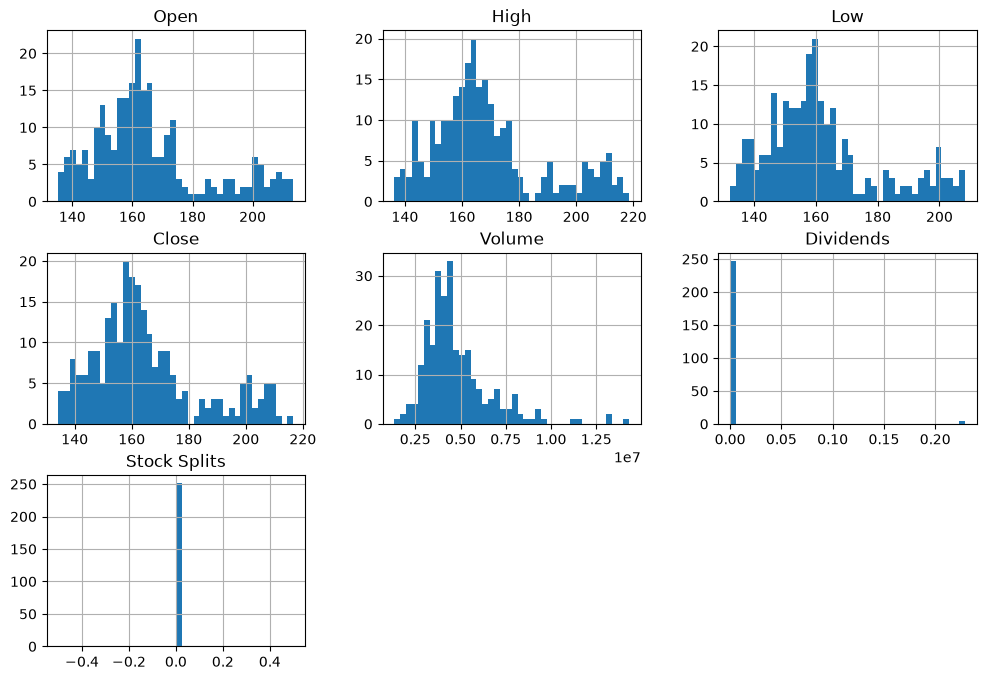

168 83
Buy & hold     Sharpe -0.03 | total   -0.5% | maxDD -19.7%
Momentum 20d   Sharpe -0.26 | total   -3.9% | maxDD -28.8%
Selected ARIMA(3, 1, 4) (AIC=1033.40)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  168
Model:                 ARIMA(3, 1, 4)   Log Likelihood                -508.699
Date:                Wed, 30 Sep 2026   AIC                           1033.398
Time:                        20:27:26   BIC                           1058.342
Sample:                             0   HQIC                          1043.522
                                - 168                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7714      0.076     10.100    

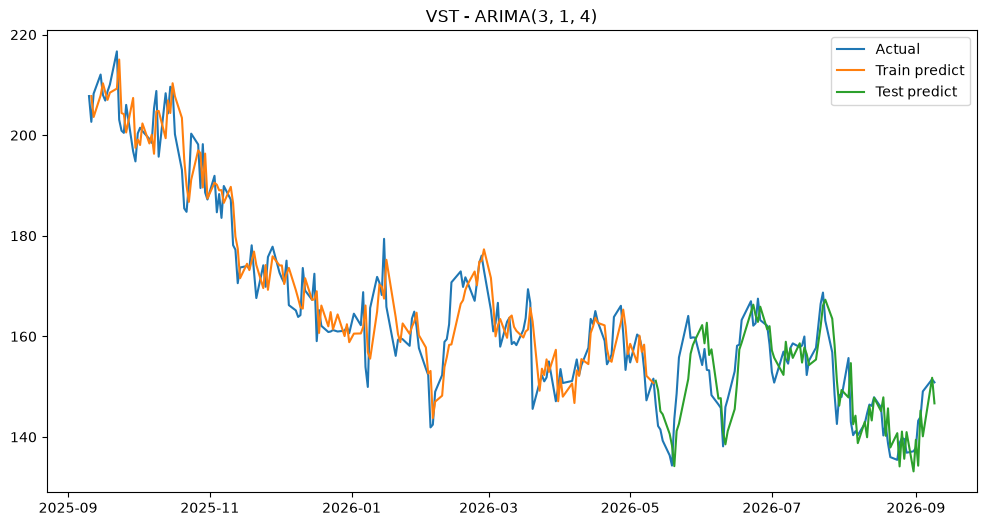

In [31]:
import sys, os
if "venv" not in sys.executable and "__file__" in globals():
    venv_python = os.path.join(
        os.path.dirname(__file__), "venv",
        "Scripts" if os.name == "nt" else "bin",
        "python.exe" if os.name == "nt" else "python",
    )
    os.execv(venv_python, [sys.executable, __file__])

import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

try:
    DATA_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    DATA_DIR = os.getcwd()

def load_yf_data(symbol, end_date, start_date):
    end_date = end_date
    start_date = start_date

    csv_path = os.path.join(DATA_DIR, f"{symbol}_{start_date}_{end_date}.csv")

    if os.path.exists(csv_path):
        print(f"Loading cached data from {csv_path}")
        data = pd.read_csv(csv_path, index_col=0)
        data.index = pd.to_datetime(data.index, utc=True).tz_convert("America/New_York")
        data.index.name = "Date"
    else:
        data = yf.Ticker(symbol).history(
            start=start_date,
            end=end_date,
        )
        data.to_csv(csv_path)
        print(f"Saved data to {csv_path}")

    return data


def select_order(series, d=1, max_p=5, max_q=5):
    best_aic, best_order = np.inf, (1, d, 0)
    for p, q in itertools.product(range(max_p + 1), range(max_q + 1)):
        if p == 0 and q == 0:
            continue
        try:
            aic = ARIMA(series, order=(p, d, q)).fit().aic
        except Exception:
            continue
        if aic < best_aic:
            best_aic, best_order = aic, (p, d, q)
    print(f"Selected ARIMA{best_order} (AIC={best_aic:.2f})")
    return best_order


def walk_forward_forecast(fitted, test_values):
    preds = []
    res = fitted
    for actual in test_values:
        preds.append(res.forecast(steps=1)[0])
        res = res.append([actual], refit=False)
    return np.array(preds)

def backtest(position, ret, cost_bps=5):
    held = position.fillna(0).shift(1).fillna(0)
    turnover = held.diff().abs().fillna(held.abs())
    return held * ret - turnover * cost_bps / 1e4


def summarize(net, name, periods=252):
    net = net.dropna()
    sharpe = net.mean() / net.std() * np.sqrt(periods)
    equity = np.exp(net.cumsum())
    max_dd = (equity / equity.cummax() - 1).min()
    print(f"{name:<14} Sharpe {sharpe:5.2f} | total {equity.iloc[-1] - 1:7.1%} | maxDD {max_dd:6.1%}")


yf_data = load_yf_data("VST", "2026-09-10", "2025-09-10")
yf_data.info()

yf_data.hist(bins=40, figsize=(12, 8))
plt.show()

close = yf_data["Close"].astype(float)
dates = close.index
values = close.values

train_ratio = 0.67
train_size = int(len(values) * train_ratio)
train, test = values[:train_size], values[train_size:]
print(train_size, len(values) - train_size)

ret = np.log(close).diff()
test_ret = ret.iloc[train_size:]

summarize(backtest(pd.Series(1.0, index=close.index), ret).iloc[train_size:], "Buy & hold")

mom_pos = np.sign(close.pct_change(20))
summarize(backtest(mom_pos, ret).iloc[train_size:], "Momentum 20d")

order = select_order(train, d=1)
model = ARIMA(train, order=order).fit()
print(model.summary())

d = order[1]
trainPredict = model.fittedvalues.copy()
trainPredict[:d] = np.nan

testPredict = walk_forward_forecast(model, test)

train_rmse = np.sqrt(mean_squared_error(train[d:], trainPredict[d:]))
test_rmse = np.sqrt(mean_squared_error(test, testPredict))

naive_pred = np.r_[train[-1], test[:-1]]
naive_rmse = np.sqrt(mean_squared_error(test, naive_pred))

print(f"Train RMSE: {train_rmse:.3f}")
print(f"Test  RMSE: {test_rmse:.3f}")
print(f"Naive baseline test RMSE: {naive_rmse:.3f}")

pred_full = pd.Series(np.nan, index=dates)
pred_full.iloc[train_size:] = testPredict

up_or_down = np.sign(pred_full - close.shift(1))

arima_pos = up_or_down.shift(-1)

summarize(backtest(arima_pos, ret).iloc[train_size:], "ARIMA signal")

trainPredictPlot = np.full(len(values), np.nan)
trainPredictPlot[:train_size] = trainPredict

testPredictPlot = np.full(len(values), np.nan)
testPredictPlot[train_size:] = testPredict

plt.figure(figsize=(12, 6))
plt.plot(dates, values, label="Actual")
plt.plot(dates, trainPredictPlot, label="Train predict")
plt.plot(dates, testPredictPlot, label="Test predict")
plt.title(f"VST - ARIMA{order}")
plt.legend()
plt.show()


Timing self-check passed.
Loading cached data from c:\Users\Conner\Desktop\github_repository\StockAnalysisBot\VST_2019-01-01_2026-09-30.csv

=== VST: 1556 train days, 389 test days (2025-03-13 to 2026-09-29) ===
Selected ARIMA(2, 0, 0) (AIC=-6675.02, 0 failed fits)

Forecast quality (test):
  ARIMA RMSE           0.03262
  Zero-forecast RMSE   0.03257
  Train-mean RMSE      0.03257
  Hit rate             0.51157

Test-period results (cost = 5 bps):
                 Sharpe   Sharpe 95% CI Total return  Max DD Ann. turnover Trades
Buy & hold         0.19  [-1.44,  1.81]        16.7%  -38.0%           0.0      0
Momentum 20d      -1.05  [-2.62,  0.54]       -56.7%  -66.8%          53.1     41
ARIMA long/short   0.90  [-0.71,  2.50]       104.4%  -37.3%         222.2    172
ARIMA long/flat    0.64  [-1.00,  2.36]        54.5%  -27.8%         110.8    171

Cost sensitivity (test Sharpe):
         ARIMA long/short  ARIMA long/flat
0 bps                1.11             0.76
5 bps             

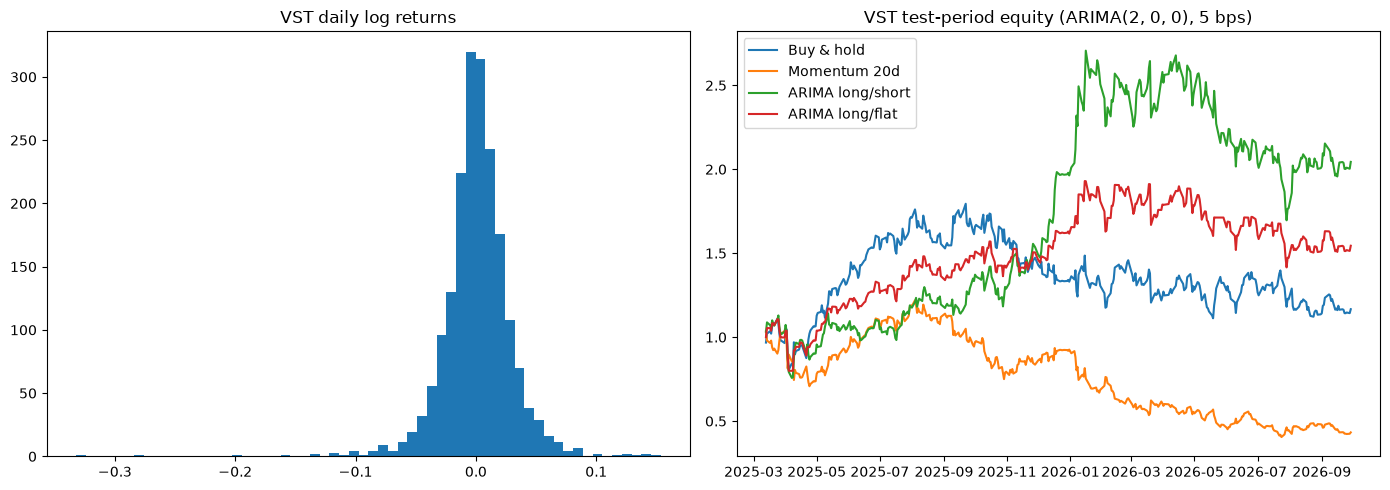

In [38]:
from __future__ import annotations

import itertools
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA


SYMBOLS = ["VST"]
START, END = "2019-01-01", "2026-09-30"
TRAIN_RATIO = 0.80
MAX_P, MAX_Q = 3, 3
REFIT_EVERY = 20   
MOMENTUM_WINDOW = 20
COST_BPS = 5                
COST_SWEEP = (0, 5, 10, 20, 100)
RISK_FREE = 0.0         
PERIODS = 252
N_BOOT = 2000

try:
    DATA_DIR = Path(__file__).resolve().parent
except NameError:  # interactive session
    DATA_DIR = Path.cwd()


def load_prices(symbol: str, start: str, end: str) -> pd.DataFrame:

    path = DATA_DIR / f"{symbol}_{start}_{end}.csv"
    if path.exists():
        print(f"Loading cached data from {path}")
        df = pd.read_csv(path, index_col=0)
    else:
        df = yf.Ticker(symbol).history(start=start, end=end)
        if df.empty:
            raise ValueError(f"No data returned for {symbol}")
        df.to_csv(path)
        print(f"Saved data to {path}")

    idx = pd.to_datetime(df.index, utc=True).tz_convert("America/New_York")
    df.index = idx.tz_localize(None).normalize()
    df.index.name = "Date"
    return df


def select_order(series: np.ndarray, d: int = 0, max_p: int = MAX_P, max_q: int = MAX_Q):

    best_aic, best_order, failures = np.inf, (0, d, 0), 0
    for p, q in itertools.product(range(max_p + 1), range(max_q + 1)):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                aic = ARIMA(series, order=(p, d, q)).fit().aic
        except Exception:
            failures += 1
            continue
        if aic < best_aic:
            best_aic, best_order = aic, (p, d, q)
    print(f"Selected ARIMA{best_order} (AIC={best_aic:.2f}, {failures} failed fits)")
    return best_order


def walk_forward_forecast(ret: pd.Series, start: int, order, refit_every: int = REFIT_EVERY) -> pd.Series:

    values = ret.to_numpy()
    out = pd.Series(np.nan, index=ret.index)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = ARIMA(values[:start], order=order).fit()
        steps = 0
        for i in range(start - 1, len(values) - 1):
            out.iloc[i] = float(np.asarray(res.forecast(1))[0])
            steps += 1
            if steps % refit_every == 0:
                res = ARIMA(values[: i + 2], order=order).fit()
            else:
                res = res.append(values[i + 1 : i + 2], refit=False)
    return out


def backtest(signal: pd.Series, ret: pd.Series, cost_bps: float = COST_BPS):
    """Signal at close of t is held over t+1. Returns (net, held, turnover)."""
    pos = signal.reindex(ret.index).fillna(0.0)
    held = pos.shift(1).fillna(0.0)
    turnover = held.diff().abs().fillna(held.abs())
    net = held * ret - turnover * cost_bps / 1e4
    return net, held, turnover


def sharpe(net: pd.Series) -> float:
    excess = net - RISK_FREE / PERIODS
    sd = excess.std()
    return float(excess.mean() / sd * np.sqrt(PERIODS)) if sd > 0 else np.nan


def sharpe_ci(net: pd.Series, n_boot: int = N_BOOT, seed: int = 0):
    """95% iid-bootstrap CI for the Sharpe ratio (ignores autocorrelation)."""
    rng = np.random.default_rng(seed)
    x = net.to_numpy() - RISK_FREE / PERIODS
    samples = rng.choice(x, size=(n_boot, len(x)), replace=True)
    sd = samples.std(axis=1, ddof=1)
    s = np.where(sd > 0, samples.mean(axis=1) / np.where(sd > 0, sd, 1) * np.sqrt(PERIODS), np.nan)
    return tuple(np.nanpercentile(s, [2.5, 97.5]))


def performance(net: pd.Series, held: pd.Series, turnover: pd.Series) -> dict:
    equity = np.exp(net.cumsum())
    lo, hi = sharpe_ci(net)
    return {
        "Sharpe": sharpe(net),
        "Sharpe 95% CI": f"[{lo:5.2f}, {hi:5.2f}]",
        "Total return": equity.iloc[-1] - 1,
        "Max DD": (equity / equity.cummax() - 1).min(),
        "Ann. turnover": turnover.mean() * PERIODS,
        "Trades": int((turnover > 0).sum()),
    }


def forecast_metrics(pred: np.ndarray, actual: np.ndarray, train_mean: float) -> dict:
    rmse = lambda e: float(np.sqrt(np.mean(e**2)))
    return {
        "ARIMA RMSE": rmse(actual - pred),
        "Zero-forecast RMSE": rmse(actual),
        "Train-mean RMSE": rmse(actual - train_mean),
        "Hit rate": float((np.sign(pred) == np.sign(actual)).mean()),
    }


def self_check():
    rng = np.random.default_rng(1)
    idx = pd.bdate_range("2020-01-01", periods=500)
    ret = pd.Series(rng.normal(0, 0.02, len(idx)), index=idx)

    oracle = np.sign(ret.shift(-1))
    net, _, _ = backtest(oracle, ret, cost_bps=0)
    assert np.isclose(net.sum(), ret.iloc[1:].abs().sum()), "oracle timing is off"

    net, _, _ = backtest(np.sign(ret), ret, cost_bps=0)
    assert net.sum() < 0.5 * ret.abs().sum(), "same-day look-ahead detected"
    print("Timing self-check passed.")


def run_symbol(symbol: str):
    prices = load_prices(symbol, START, END)
    close = prices["Close"].astype(float)
    ret = np.log(close).diff().dropna()

    n = int(len(ret) * TRAIN_RATIO)
    train, test = ret.iloc[:n], ret.iloc[n:]
    print(f"\n=== {symbol}: {len(train)} train days, {len(test)} test days "
          f"({test.index[0].date()} to {test.index[-1].date()}) ===")

    order = select_order(train.to_numpy(), d=0)
    fc = walk_forward_forecast(ret, n, order)

    pred = fc.iloc[n - 1 : -1].to_numpy()
    actual = test.to_numpy()
    fm = forecast_metrics(pred, actual, train.mean())
    print("\nForecast quality (test):")
    for k, v in fm.items():
        print(f"  {k:<20} {v:.5f}")

    signals = {
        "Buy & hold": pd.Series(1.0, index=ret.index),
        f"Momentum {MOMENTUM_WINDOW}d": np.sign(close.pct_change(MOMENTUM_WINDOW)),
        "ARIMA long/short": np.sign(fc),
        "ARIMA long/flat": (fc > 0).astype(float),
    }

    rows, curves = {}, {}
    for name, sig in signals.items():
        net, held, turn = backtest(sig, ret, COST_BPS)
        net_t, held_t, turn_t = net.iloc[n:], held.iloc[n:], turn.iloc[n:]
        rows[name] = performance(net_t, held_t, turn_t)
        curves[name] = np.exp(net_t.cumsum())

    table = pd.DataFrame(rows).T
    fmt = {"Sharpe": "{:.2f}".format, "Total return": "{:.1%}".format,
           "Max DD": "{:.1%}".format, "Ann. turnover": "{:.1f}".format}
    print(f"\nTest-period results (cost = {COST_BPS} bps):")
    print(table.to_string(formatters={k: v for k, v in fmt.items() if k in table}))

    print("\nCost sensitivity (test Sharpe):")
    sweep = {
        name: [sharpe(backtest(signals[name], ret, c)[0].iloc[n:]) for c in COST_SWEEP]
        for name in ("ARIMA long/short", "ARIMA long/flat")
    }
    print(pd.DataFrame(sweep, index=[f"{c} bps" for c in COST_SWEEP]).round(2).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(ret, bins=60)
    axes[0].set_title(f"{symbol} daily log returns")
    for name, eq in curves.items():
        axes[1].plot(eq.index, eq.values, label=name)
    axes[1].set_title(f"{symbol} test-period equity (ARIMA{order}, {COST_BPS} bps)")
    axes[1].legend()
    fig.tight_layout()
    return ret, order

def main():
    self_check()
    for symbol in SYMBOLS:
        ret, order = run_symbol(symbol)

        final = ARIMA(ret.to_numpy(), order=order).fit()
        print(f"\n{symbol}: ARIMA{order} fit on {len(ret)} days, last date {ret.index[-1].date()}")
        print(final.summary())
        next_ret = float(np.asarray(final.forecast(1))[0])
        print(f"Forecast next-day log return: {next_ret:+.4%}")
    plt.show()


if __name__ == "__main__":
    main()